# Equity Analysis with Python - Introduction (Part 2)

Note: __yfinance can be unstable/unreliable from time to time__ when it comes to downloading fundamental data with the ticker object. In particular, __ticker.get_info()__ can be flawed.

__Action required__: Check for the __latest yfinance versions__ and update with the following command (Anaconda Prompt / Terminal):

pip install yfinance --upgrade

In the following, I have added an __alternative Yahoo Finance API Wrapper__, __yahooquery__

__Action required: Please install yahooquery with the following command (Anaconda Prompt / Terminal):__

pip install yahooquery --upgrade

Note: 
- Please make sure you have installed the __latest__ yahooquery version (if not, please upgrade). 

__Update December 2023__: Sometimes yfinance is more stable/reliable and sometimes yahooquery is more stable/reliable. Most recently, yfinance seemed to be better. In any case, __please make sure you have the latest versions installed!__

In [1]:
%pip install yahooquery

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.7/50.7 kB 2.5 MB/s eta 0:00:00


## Ticker Object

In [2]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
from yahooquery import Ticker  
plt.style.use("seaborn-v0_8")

__yfinance__

In [3]:
aapl = yf.Ticker(ticker = "AAPL")
aapl

yfinance.Ticker object <AAPL>

In [4]:
type(aapl)

yfinance.ticker.Ticker

In [5]:
aapl.analyst_price_targets

{'current': 313.39,
 'high': 400.0,
 'low': 215.0,
 'mean': 315.56668,
 'median': 315.0}

In [6]:
len(aapl.analyst_price_targets)

5

In [7]:
pd.DataFrame(aapl.analyst_price_targets , index = [0])

,current,high,low,mean,median
0,313.39,400.0,215.0,315.56668,315.0


In [8]:
pd.DataFrame(aapl.calendar, index = [0])

,Dividend Date,Ex-Dividend Date,Earnings Date,Earnings High,Earnings Low,Earnings Average,Revenue High,Revenue Low,Revenue Average
0,2026-05-14,2026-05-11,2026-07-30,1.99,1.83,1.89428,112168000000,107501000000,108900122530


In [9]:
aapl.actions

,Dividends,Stock Splits
Date,,
1987-05-11 00:00:00-04:00,0.000536,0.0
1987-06-16 00:00:00-04:00,0.000000,2.0
1987-08-10 00:00:00-04:00,0.000536,0.0
1987-11-17 00:00:00-05:00,0.000714,0.0
1988-02-12 00:00:00-05:00,0.000714,0.0
...,...,...
2025-05-12 00:00:00-04:00,0.260000,0.0
2025-08-11 00:00:00-04:00,0.260000,0.0
2025-11-10 00:00:00-05:00,0.260000,0.0


In [29]:
aapl.earnings_dates

,EPS Estimate,Reported EPS,Surprise(%)
Earnings Date,,,
2026-07-30 16:00:00-04:00,1.89,NaN,NaN
2026-04-30 16:00:00-04:00,1.94,2.01,3.46
2026-01-29 16:00:00-05:00,2.67,2.84,6.34
2025-10-30 16:00:00-04:00,1.77,1.85,4.52
2025-07-31 16:00:00-04:00,1.43,1.57,10.12
2025-05-01 16:00:00-04:00,1.62,1.65,1.69
2025-01-30 16:00:00-05:00,2.34,2.40,2.52
2024-10-31 16:00:00-04:00,0.95,0.97,2.48
2024-08-01 16:00:00-04:00,1.34,1.40,4.36


<Axes: xlabel='Earnings Date'>

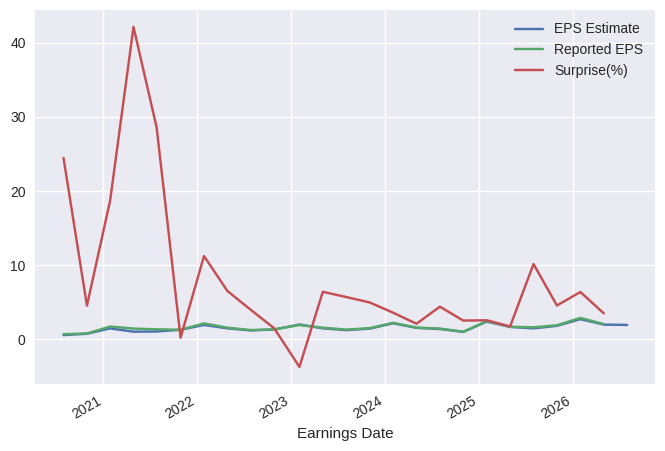

In [10]:
aapl.earnings_dates.plot()

In [11]:
aapl.history() # historical price and volume data

,Open,High,Low,Close,Volume,Dividends,Stock Splits
Date,,,,,,,
2026-06-09 00:00:00-04:00,300.279999,300.750000,287.779999,290.549988,70108800,0.0,0.0
2026-06-10 00:00:00-04:00,290.739990,294.750000,287.380005,291.579987,52793300,0.0,0.0
2026-06-11 00:00:00-04:00,293.720001,297.000000,289.589996,295.630005,42572500,0.0,0.0
2026-06-12 00:00:00-04:00,296.029999,297.140015,289.619995,291.130005,38742100,0.0,0.0
2026-06-15 00:00:00-04:00,294.119995,297.779999,291.700012,296.420013,45732600,0.0,0.0
2026-06-16 00:00:00-04:00,295.250000,300.480011,293.970001,299.239990,39874400,0.0,0.0
2026-06-17 00:00:00-04:00,300.850006,302.070007,294.359985,295.950012,42745100,0.0,0.0
2026-06-18 00:00:00-04:00,298.109985,300.570007,295.619995,298.010010,85962200,0.0,0.0
2026-06-22 00:00:00-04:00,297.309998,302.420013,296.760010,297.010010,44879900,0.0,0.0


In [12]:
aapl.get_info()

{'address1': 'One Apple Park Way',
 'city': 'Cupertino',
 'state': 'CA',
 'zip': '95014',
 'country': 'United States',
 'phone': '(408) 996-1010',
 'website': 'https://www.apple.com',
 'industry': 'Consumer Electronics',
 'industryKey': 'consumer-electronics',
 'industryDisp': 'Consumer Electronics',
 'sector': 'Technology',
 'sectorKey': 'technology',
 'sectorDisp': 'Technology',
 'longBusinessSummary': 'Apple Inc. designs, manufactures, and markets smartphones, personal computers, tablets, wearables, and accessories worldwide. The company offers iPhone, a line of smartphones; Mac, a line of personal computers; iPad, a line of multi-purpose tablets; and wearables, home, and accessories comprising AirPods, Apple Vision Pro, Apple TV, Apple Watch, Beats products, and HomePod, as well as Apple branded and third-party accessories. It also provides AppleCare support and cloud services; and operates various platforms, including the App Store that allow customers to discover and download app

In [13]:
info = pd.Series(aapl.get_info() , name ="APPLE")
info

,APPLE
address1,One Apple Park Way
city,Cupertino
state,CA
zip,95014
country,United States
...,...
gmtOffSetMilliseconds,-14400000
market,us_market
esgPopulated,False
displayName,Apple


In [14]:
len(info)

184

In [15]:
info.head(50)

,APPLE
address1,One Apple Park Way
city,Cupertino
state,CA
zip,95014
country,United States
phone,(408) 996-1010
website,https://www.apple.com
industry,Consumer Electronics
industryKey,consumer-electronics
industryDisp,Consumer Electronics


In [16]:
info['longBusinessSummary'].split(",")

['Apple Inc. designs',
 ' manufactures',
 ' and markets smartphones',
 ' personal computers',
 ' tablets',
 ' wearables',
 ' and accessories worldwide. The company offers iPhone',
 ' a line of smartphones; Mac',
 ' a line of personal computers; iPad',
 ' a line of multi-purpose tablets; and wearables',
 ' home',
 ' and accessories comprising AirPods',
 ' Apple Vision Pro',
 ' Apple TV',
 ' Apple Watch',
 ' Beats products',
 ' and HomePod',
 ' as well as Apple branded and third-party accessories. It also provides AppleCare support and cloud services; and operates various platforms',
 ' including the App Store that allow customers to discover and download applications and digital content',
 ' such as books',
 ' music',
 ' video',
 ' games',
 ' and podcasts',
 ' as well as advertising services include third-party licensing arrangements and its own advertising platforms. In addition',
 ' the company offers various subscription-based services',
 ' such as Apple Arcade',
 ' a game subscripti

In [17]:
#aapl.

__NEW__ (Jan 2023): get_fast_info (before: fast_info, now: get_fast_info())

In [18]:
aapl.fast_info # OLD

lazy-loading dict with keys = ['currency', 'dayHigh', 'dayLow', 'exchange', 'fiftyDayAverage', 'lastPrice', 'lastVolume', 'marketCap', 'open', 'previousClose', 'quoteType', 'regularMarketPreviousClose', 'shares', 'tenDayAverageVolume', 'threeMonthAverageVolume', 'timezone', 'twoHundredDayAverage', 'yearChange', 'yearHigh', 'yearLow']

In [19]:
fast_info = aapl.get_fast_info() # NEW! before: fast_info
fast_info

lazy-loading dict with keys = ['currency', 'dayHigh', 'dayLow', 'exchange', 'fiftyDayAverage', 'lastPrice', 'lastVolume', 'marketCap', 'open', 'previousClose', 'quoteType', 'regularMarketPreviousClose', 'shares', 'tenDayAverageVolume', 'threeMonthAverageVolume', 'timezone', 'twoHundredDayAverage', 'yearChange', 'yearHigh', 'yearLow']

In [20]:
pd.options.display.float_format = '{:,.2f}'.format

In [21]:
aapl.income_stmt

,2025-09-30,2024-09-30,2023-09-30,2022-09-30,2021-09-30
Tax Effect Of Unusual Items,0.00,0.00,0.00,0.00,NaN
Tax Rate For Calcs,0.16,0.24,0.15,0.16,NaN
Normalized EBITDA,"144,748,000,000.00","134,661,000,000.00","125,820,000,000.00","130,541,000,000.00",NaN
Net Income From Continuing Operation Net Minority Interest,"112,010,000,000.00","93,736,000,000.00","96,995,000,000.00","99,803,000,000.00",NaN
Reconciled Depreciation,"11,698,000,000.00","11,445,000,000.00","11,519,000,000.00","11,104,000,000.00",NaN
Reconciled Cost Of Revenue,"220,960,000,000.00","210,352,000,000.00","214,137,000,000.00","223,546,000,000.00",NaN
EBITDA,"144,748,000,000.00","134,661,000,000.00","125,820,000,000.00","130,541,000,000.00",NaN
EBIT,"133,050,000,000.00","123,216,000,000.00","114,301,000,000.00","119,437,000,000.00",NaN
Net Interest Income,NaN,NaN,"-183,000,000.00","-106,000,000.00","198,000,000.00"
Interest Expense,NaN,NaN,"3,933,000,000.00","2,931,000,000.00","2,645,000,000.00"


__yahooquery__

In [22]:
%pip install yahooquery --upgrade

In [23]:
import yahooquery as yq

In [24]:
aapl2 = yq.Ticker("AAPL")
aapl2

In [25]:
aapl2.history()

open   high    low  close    volume  adjclose  dividends
symbol date                                                                 
AAPL   2026-01-02 272.26 277.84 269.00 271.01  37838100    270.51       0.00
       2026-01-05 270.64 271.51 266.14 267.26  45647200    266.76       0.00
       2026-01-06 267.00 267.55 262.12 262.36  52352100    261.87       0.00
       2026-01-07 263.20 263.68 259.81 260.33  48309800    259.85       0.00
       2026-01-08 257.02 259.29 255.70 259.04  50419300    258.56       0.00
...                  ...    ...    ...    ...       ...       ...        ...
       2026-07-01 293.44 296.59 289.20 294.38  50164200    294.38       0.00
       2026-07-02 294.12 309.42 293.68 308.63  75352800    308.63       0.00
       2026-07-06 307.36 314.20 307.00 312.66  53590000    312.66       0.00
       2026-07-07 315.29 315.48 310.15 310.66  42490000    310.66       0.00
       2026-07-08 311.66 314.81 307.05 313.39  38466049    313.39       0.00

[128 rows x 7 columns]

In [26]:
aapl2.industry_trend

{'AAPL': {'maxAge': 1, 'symbol': None, 'estimates': []}}

In [27]:
aapl2.esg_scores

{'AAPL': 'No fundamentals data found for symbol: AAPL'}

In [ ]:
pd.set_option('display.max_colwidth', None)  

In [ ]:
aapl2.corporate_guidance

id significance  \
symbol date                               
AAPL   2016-07-26  3411927            1   
       2016-07-27  3413066            1   
       2016-10-25  3460676            1   
       2016-10-25  3460645            1   
       2016-12-20  3498462            1   
...                    ...          ...   
       2025-10-30  5038307            1   
       2025-10-30  5038292            1   
       2025-11-06  5042321            1   
       2026-04-22  5095523            1   
       2026-04-30  5100356            1   

                                                                                                      headline  \
symbol date                                                                                                      
AAPL   2016-07-26                                                    Apple reports Q3 earnings per share $1.42   
       2016-07-27                            Apple sees utilizing about $13 bln for capex during 2016 - filing   
       2016-10-25         Apple CFO says 'impossible to know' effect of Samsung Note 7 recall on iPhone demand   
       2016-10-25                                                          Apple's 4th-qtr revenue falls 9 pct   
       2016-12-20                       Nike CFO- Expect Q3 reported revenue to grow in mid single-digit range   
...                                                                                                        ...   
       2025-10-30              Apple CEO Cook Says Supply Constrained Today On Several Models Of The iPhone 17   
       2025-10-30  Apple Expects 'Double Digit' Year Over Year Sales Growth For iPhone Segment In Q1, CEO Says   
       2025-11-06                MP Materials CEO Expects Company To Return To Profitability In Fourth Quarter   
       2026-04-22                Google Says Gemini Will Help Apple To Power Personalized Siri, Coming In 2026   
       2026-04-30                   Apple Posts Q2 Revenue Of $111.18 Billion Vs IBES Estimate $109.66 Billion   

                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                    description  \
symbol date                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                               

In [30]:
aapl.financials

,2025-09-30,2024-09-30,2023-09-30,2022-09-30,2021-09-30
Tax Effect Of Unusual Items,0.00,0.00,0.00,0.00,NaN
Tax Rate For Calcs,0.16,0.24,0.15,0.16,NaN
Normalized EBITDA,"144,748,000,000.00","134,661,000,000.00","125,820,000,000.00","130,541,000,000.00",NaN
Net Income From Continuing Operation Net Minority Interest,"112,010,000,000.00","93,736,000,000.00","96,995,000,000.00","99,803,000,000.00",NaN
Reconciled Depreciation,"11,698,000,000.00","11,445,000,000.00","11,519,000,000.00","11,104,000,000.00",NaN
Reconciled Cost Of Revenue,"220,960,000,000.00","210,352,000,000.00","214,137,000,000.00","223,546,000,000.00",NaN
EBITDA,"144,748,000,000.00","134,661,000,000.00","125,820,000,000.00","130,541,000,000.00",NaN
EBIT,"133,050,000,000.00","123,216,000,000.00","114,301,000,000.00","119,437,000,000.00",NaN
Net Interest Income,NaN,NaN,"-183,000,000.00","-106,000,000.00","198,000,000.00"
Interest Expense,NaN,NaN,"3,933,000,000.00","2,931,000,000.00","2,645,000,000.00"


In [ ]:
%pip install yfinance --upgrade



   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 144.2/144.2 kB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.1/11.1 MB 51.0 MB/s eta 0:00:0000:010:01
  Attempting uninstall: curl_cffi
    Found existing installation: curl_cffi 0.14.0
    Uninstalling curl_cffi-0.14.0:
      Successfully uninstalled curl_cffi-0.14.0
  Attempting uninstall: yfinance
    Found existing installation: yfinance 0.2.66
    Uninstalling yfinance-0.2.66:
      Successfully uninstalled yfinance-0.2.66


In [32]:
import yfinance as yf
yf.__version__

'0.2.66'

In [33]:
import yahooquery as yq
yq.__version__

'2.4.1'

In [34]:
aapl2 = yq.Ticker("AAPL")
aapl2

In [35]:
aapl2.index_trend

{'AAPL': {'maxAge': 1,
  'symbol': 'SP5',
  'estimates': [{'period': '0q', 'growth': 0.2085},
   {'period': '+1q', 'growth': 0.2208},
   {'period': '0y', 'growth': 0.23719999},
   {'period': '+1y', 'growth': 0.1814},
   {'period': 'LTG', 'growth': 0.122}]}}

In [36]:
aapl2.key_stats

{'AAPL': {'maxAge': 1,
  'priceHint': 2,
  'enterpriseValue': 4578977775616,
  'forwardPE': 32.614388,
  'profitMargins': 0.27152002,
  'floatShares': 14662534368,
  'sharesOutstanding': 14687356000,
  'sharesShort': 144248476,
  'sharesShortPriorMonth': 138782718,
  'sharesShortPreviousMonthDate': '2026-05-15 00:00:00',
  'dateShortInterest': '2026-06-15 00:00:00',
  'sharesPercentSharesOut': 0.0098,
  'heldPercentInsiders': 0.01631,
  'heldPercentInstitutions': 0.65769,
  'shortRatio': 2.88,
  'shortPercentOfFloat': 0.0098,
  'beta': 1.097,
  'impliedSharesOutstanding': 14687356000,
  'category': None,
  'bookValue': 7.26,
  'priceToBook': 43.166668,
  'fundFamily': None,
  'legalType': None,
  'lastFiscalYearEnd': '2025-09-27 00:00:00',
  'nextFiscalYearEnd': '2026-09-27 00:00:00',
  'mostRecentQuarter': '2026-03-28 00:00:00',
  'earningsQuarterlyGrowth': 0.194,
  'netIncomeToCommon': 122575003648,
  'trailingEps': 8.26,
  'forwardEps': 9.60895,
  'pegRatio': 2.53,
  'lastSplitFacto

In [37]:
pd.DataFrame(aapl2.key_stats)

,AAPL
maxAge,1
priceHint,2
enterpriseValue,4578977775616
forwardPE,32.61
profitMargins,0.27
floatShares,14662534368
sharesOutstanding,14687356000
sharesShort,144248476
sharesShortPriorMonth,138782718
sharesShortPreviousMonthDate,2026-05-15 00:00:00


## Price, Shares Outstanding & Market Capitalization

In [ ]:
%pip install yahooquery --upgrade

In [ ]:
import yahooquery as yq

In [39]:
aapl = yf.Ticker(ticker = "AAPL")
aapl

yfinance.Ticker object <AAPL>

In [40]:
aapl_yq = yq.Ticker("AAPL")
aapl_yq

In [41]:
info = aapl.info #yfinance
info

{'address1': 'One Apple Park Way',
 'city': 'Cupertino',
 'state': 'CA',
 'zip': '95014',
 'country': 'United States',
 'phone': '(408) 996-1010',
 'website': 'https://www.apple.com',
 'industry': 'Consumer Electronics',
 'industryKey': 'consumer-electronics',
 'industryDisp': 'Consumer Electronics',
 'sector': 'Technology',
 'sectorKey': 'technology',
 'sectorDisp': 'Technology',
 'longBusinessSummary': 'Apple Inc. designs, manufactures, and markets smartphones, personal computers, tablets, wearables, and accessories worldwide. The company offers iPhone, a line of smartphones; Mac, a line of personal computers; iPad, a line of multi-purpose tablets; and wearables, home, and accessories comprising AirPods, Apple Vision Pro, Apple TV, Apple Watch, Beats products, and HomePod, as well as Apple branded and third-party accessories. It also provides AppleCare support and cloud services; and operates various platforms, including the App Store that allow customers to discover and download app

In [42]:
info = pd.Series(info)
info

,0
address1,One Apple Park Way
city,Cupertino
state,CA
zip,95014
country,United States
...,...
regularMarketPrice,313.39
shortName,Apple Inc.
longName,Apple Inc.
displayName,Apple


In [43]:
fast_info = aapl.fast_info    # yfinance Alt2
fast_info

lazy-loading dict with keys = ['currency', 'dayHigh', 'dayLow', 'exchange', 'fiftyDayAverage', 'lastPrice', 'lastVolume', 'marketCap', 'open', 'previousClose', 'quoteType', 'regularMarketPreviousClose', 'shares', 'tenDayAverageVolume', 'threeMonthAverageVolume', 'timezone', 'twoHundredDayAverage', 'yearChange', 'yearHigh', 'yearLow']

In [46]:
fast_info.items()

[('currency', 'USD'),
 ('dayHigh', 314.80999755859375),
 ('dayLow', 307.051513671875),
 ('exchange', 'NMS'),
 ('fiftyDayAverage', 295.0573999023438),
 ('lastPrice', 313.3900146484375),
 ('lastVolume', 38466049),
 ('marketCap', 4602870711986.816),
 ('open', 311.6600036621094),
 ('previousClose', 311.421),
 ('quoteType', 'EQUITY'),
 ('regularMarketPreviousClose', 310.6600036621094),
 ('shares', 14687356000),
 ('tenDayAverageVolume', 82700620),
 ('threeMonthAverageVolume', 54012343),
 ('timezone', 'America/New_York'),
 ('twoHundredDayAverage', 271.422349319458),
 ('yearChange', 0.47134604793098295),
 ('yearHigh', 317.3999938964844),
 ('yearLow', 201.5)]

__Market Capitalization__

In [44]:
market_cap = info.marketCap #yfinance Alt1
market_cap

4602870628352

In [45]:
market_cap = fast_info["market_cap"] #yfinance Alt2
market_cap

4602870711986.816

In [47]:
aapl_yq = yq.Ticker("AAPL")
aapl_yq

In [48]:
aapl_yq.summary_detail.items()

dict_items([('AAPL', {'maxAge': 1, 'priceHint': 2, 'previousClose': 310.66, 'open': 311.66, 'dayLow': 307.0515, 'dayHigh': 314.81, 'regularMarketPreviousClose': 310.66, 'regularMarketOpen': 311.66, 'regularMarketDayLow': 307.0515, 'regularMarketDayHigh': 314.81, 'dividendRate': 1.08, 'dividendYield': 0.0034999999, 'exDividendDate': '2026-05-11 00:00:00', 'payoutRatio': 0.1259, 'fiveYearAvgDividendYield': 0.5, 'beta': 1.097, 'trailingPE': 37.940678, 'forwardPE': 32.614388, 'volume': 38466049, 'regularMarketVolume': 38466049, 'averageVolume': 54224081, 'averageVolume10days': 82694270, 'averageDailyVolume10Day': 82694270, 'bid': 313.86, 'ask': 314.1, 'bidSize': 100, 'askSize': 200, 'marketCap': 4602870628352, 'nonDilutedMarketCap': 4532958682280, 'fiftyTwoWeekLow': 201.5, 'fiftyTwoWeekHigh': 317.4, 'allTimeHigh': 317.4, 'allTimeLow': 0.049107, 'priceToSalesTrailing12Months': 10.195929, 'fiftyDayAverage': 295.0574, 'twoHundredDayAverage': 271.42236, 'trailingAnnualDividendRate': 1.04, 'tra

In [49]:
aapl_yq.summary_detail["AAPL"].keys()

dict_keys(['maxAge', 'priceHint', 'previousClose', 'open', 'dayLow', 'dayHigh', 'regularMarketPreviousClose', 'regularMarketOpen', 'regularMarketDayLow', 'regularMarketDayHigh', 'dividendRate', 'dividendYield', 'exDividendDate', 'payoutRatio', 'fiveYearAvgDividendYield', 'beta', 'trailingPE', 'forwardPE', 'volume', 'regularMarketVolume', 'averageVolume', 'averageVolume10days', 'averageDailyVolume10Day', 'bid', 'ask', 'bidSize', 'askSize', 'marketCap', 'nonDilutedMarketCap', 'fiftyTwoWeekLow', 'fiftyTwoWeekHigh', 'allTimeHigh', 'allTimeLow', 'priceToSalesTrailing12Months', 'fiftyDayAverage', 'twoHundredDayAverage', 'trailingAnnualDividendRate', 'trailingAnnualDividendYield', 'currency', 'fromCurrency', 'toCurrency', 'lastMarket', 'coinMarketCapLink', 'algorithm', 'tradeable'])

In [50]:
aapl_yq.summary_detail["AAPL"]["marketCap"]

4602870628352

In [51]:
market_cap = aapl_yq.summary_detail["AAPL"]["marketCap"]
market_cap

4602870628352

Market capitalization refers to the __total [dollar] market value__ of a company's outstanding shares of stock. Market capitalization refers to __how much a company´s equity is worth__ as determined by the stock market. <br>(source: Investopedia.com)

To calculate a company's market cap, multiply 
- the number of __outstanding shares__ 
- by the current __share price__/value

__Shares Outstanding__

In [53]:
aapl.info

{'address1': 'One Apple Park Way',
 'city': 'Cupertino',
 'state': 'CA',
 'zip': '95014',
 'country': 'United States',
 'phone': '(408) 996-1010',
 'website': 'https://www.apple.com',
 'industry': 'Consumer Electronics',
 'industryKey': 'consumer-electronics',
 'industryDisp': 'Consumer Electronics',
 'sector': 'Technology',
 'sectorKey': 'technology',
 'sectorDisp': 'Technology',
 'longBusinessSummary': 'Apple Inc. designs, manufactures, and markets smartphones, personal computers, tablets, wearables, and accessories worldwide. The company offers iPhone, a line of smartphones; Mac, a line of personal computers; iPad, a line of multi-purpose tablets; and wearables, home, and accessories comprising AirPods, Apple Vision Pro, Apple TV, Apple Watch, Beats products, and HomePod, as well as Apple branded and third-party accessories. It also provides AppleCare support and cloud services; and operates various platforms, including the App Store that allow customers to discover and download app

In [54]:
info = pd.Series(aapl.info, name = "APPLE")

In [55]:
info

,APPLE
address1,One Apple Park Way
city,Cupertino
state,CA
zip,95014
country,United States
...,...
regularMarketPrice,313.39
shortName,Apple Inc.
longName,Apple Inc.
displayName,Apple


In [56]:
shares = info.sharesOutstanding #yfinance
shares

14687356000

In [57]:
for key in aapl_yq.key_stats["AAPL"].keys():
    if key.lower().startswith("shares"):
        print(key)
        print("-"*50)
        print(aapl_yq.key_stats["AAPL"][key])

sharesOutstanding
--------------------------------------------------
14687356000
sharesShort
--------------------------------------------------
144248476
sharesShortPriorMonth
--------------------------------------------------
138782718
sharesShortPreviousMonthDate
--------------------------------------------------
2026-05-15 00:00:00
sharesPercentSharesOut
--------------------------------------------------
0.0098


In [58]:
shares = aapl_yq.key_stats["AAPL"]["sharesOutstanding"] #yahooquery
shares

14687356000

Shares outstanding refer to a __company's stock currently held by all its shareholders__, including share blocks held by institutional investors and restricted shares owned by the company’s officers and insiders.<br>
(source: Investopedia.com)

__Share Price__

In [59]:
market_cap / shares

313.3900089540963

In [60]:
price = info.currentPrice #yfinance Alt1
price

313.39

In [63]:
aapl_yq.financial_data

{'AAPL': {'maxAge': 86400,
  'currentPrice': 313.39,
  'targetHighPrice': 400.0,
  'targetLowPrice': 215.0,
  'targetMeanPrice': 315.56668,
  'targetMedianPrice': 315.0,
  'recommendationMean': 2.02128,
  'recommendationKey': 'buy',
  'numberOfAnalystOpinions': 42,
  'totalCash': 68507000832,
  'totalCashPerShare': 4.664,
  'ebitda': 159975997440,
  'totalDebt': 84710998016,
  'quickRatio': 0.906,
  'currentRatio': 1.07,
  'totalRevenue': 451442016256,
  'debtToEquity': 79.548,
  'revenuePerShare': 30.534,
  'returnOnAssets': 0.26229,
  'returnOnEquity': 1.4147099,
  'grossProfits': 216070995968,
  'freeCashflow': 101090746368,
  'operatingCashflow': 140222005248,
  'earningsGrowth': 0.218,
  'revenueGrowth': 0.166,
  'grossMargins': 0.47862,
  'ebitdaMargins': 0.35437,
  'operatingMargins': 0.32275,
  'profitMargins': 0.27152002,
  'financialCurrency': 'USD'}}

In [65]:
pd.DataFrame(aapl_yq.financial_data)

,AAPL
maxAge,86400
currentPrice,313.39
targetHighPrice,400.00
targetLowPrice,215.00
targetMeanPrice,315.57
targetMedianPrice,315.00
recommendationMean,2.02
recommendationKey,buy
numberOfAnalystOpinions,42
totalCash,68507000832


In [66]:
aapl_yq.financial_data["AAPL"]["currentPrice"]

313.39

In [73]:
fast_info = aapl.fast_info

In [74]:
fast_info

lazy-loading dict with keys = ['currency', 'dayHigh', 'dayLow', 'exchange', 'fiftyDayAverage', 'lastPrice', 'lastVolume', 'marketCap', 'open', 'previousClose', 'quoteType', 'regularMarketPreviousClose', 'shares', 'tenDayAverageVolume', 'threeMonthAverageVolume', 'timezone', 'twoHundredDayAverage', 'yearChange', 'yearHigh', 'yearLow']

In [75]:
price = fast_info.last_price #yfinance Alt2
price

313.3900146484375

market cap = shares outstanding * share price

In [76]:
aapl_yq.financial_data["AAPL"]["currentPrice"]

313.39

In [77]:
price = aapl_yq.financial_data["AAPL"]["currentPrice"] #yahooquery
price

313.39

In [78]:
market_cap / shares

313.3900089540963

- __Share Price__ alone is __not a meaningful__ metric to compare stocks. 
- Share Price can be "manipulated", e.g. by Stock Splits.
- Recap: __Market Cap__ is not effected by Stock Splits!

Share Price is __not__ a good Indicator for Performance/Value/Importance of a Stock! <br>
__Use Market Cap!!!__

## Equity Value, Firm Value and Financial Distress

In [83]:
info = pd.Series(aapl.info , name = "APPLE")

In [84]:
info #yfinance Alt1

,APPLE
address1,One Apple Park Way
city,Cupertino
state,CA
zip,95014
country,United States
...,...
regularMarketPrice,313.39
shortName,Apple Inc.
longName,Apple Inc.
displayName,Apple


In [90]:
fast_info = aapl.fast_info

In [91]:
fast_info #yfinance Alt2

lazy-loading dict with keys = ['currency', 'dayHigh', 'dayLow', 'exchange', 'fiftyDayAverage', 'lastPrice', 'lastVolume', 'marketCap', 'open', 'previousClose', 'quoteType', 'regularMarketPreviousClose', 'shares', 'tenDayAverageVolume', 'threeMonthAverageVolume', 'timezone', 'twoHundredDayAverage', 'yearChange', 'yearHigh', 'yearLow']

__Market Value of Equity (Market Cap)__

In [87]:
market_cap = info.marketCap #yfinance Alt1
market_cap

4602870628352

In [92]:
market_cap = fast_info["market_cap"] #yfinance Alt2
market_cap

4602870711986.816

In [94]:
aapl_yq.summary_detail

{'AAPL': {'maxAge': 1,
  'priceHint': 2,
  'previousClose': 310.66,
  'open': 311.66,
  'dayLow': 307.0515,
  'dayHigh': 314.81,
  'regularMarketPreviousClose': 310.66,
  'regularMarketOpen': 311.66,
  'regularMarketDayLow': 307.0515,
  'regularMarketDayHigh': 314.81,
  'dividendRate': 1.08,
  'dividendYield': 0.0034999999,
  'exDividendDate': '2026-05-11 00:00:00',
  'payoutRatio': 0.1259,
  'fiveYearAvgDividendYield': 0.5,
  'beta': 1.097,
  'trailingPE': 37.940678,
  'forwardPE': 32.614388,
  'volume': 38466049,
  'regularMarketVolume': 38466049,
  'averageVolume': 54224081,
  'averageVolume10days': 82694270,
  'averageDailyVolume10Day': 82694270,
  'bid': 313.86,
  'ask': 314.1,
  'bidSize': 100,
  'askSize': 200,
  'marketCap': 4602870628352,
  'nonDilutedMarketCap': 4532958682280,
  'fiftyTwoWeekLow': 201.5,
  'fiftyTwoWeekHigh': 317.4,
  'allTimeHigh': 317.4,
  'allTimeLow': 0.049107,
  'priceToSalesTrailing12Months': 10.195929,
  'fiftyDayAverage': 295.0574,
  'twoHundredDayAve

In [93]:
market_cap = aapl_yq.summary_detail["AAPL"]["marketCap"] #yahooquery
market_cap

4602870628352

__Market Value of Debt__ (Book Value a good approximation)

In [95]:
debt = info.totalDebt #yfinance
debt

84710998016

In [96]:
debt = aapl_yq.financial_data["AAPL"]["totalDebt"] #yahooquery
debt

84710998016

__Firm Value__

Equity Value = Firm Value - Market Value of Debt

In [97]:
firm_value = market_cap + debt
firm_value

4687581626368

__Firm Value__: __Total Company Value__ available to all suppliers of capital (equity & debt)

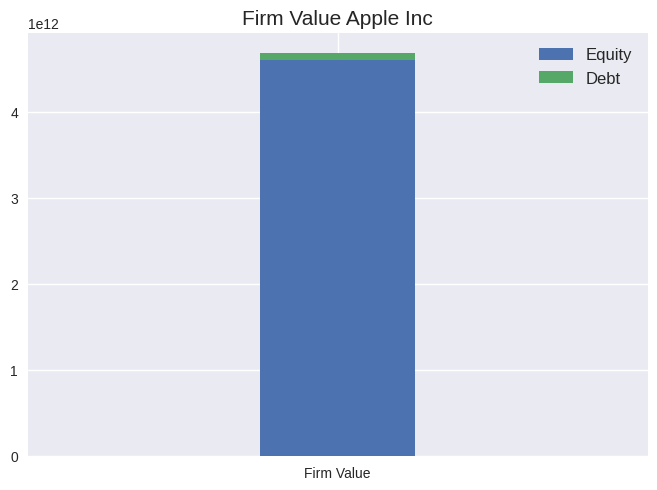

In [99]:
plt.bar("Firm Value", market_cap, label = "Equity", width = 0.5)
plt.bar("Firm Value", debt, label = "Debt", width = 0.5, bottom = market_cap)
plt.xlim(-1, 1)
plt.legend(fontsize = 12)
plt.title("Firm Value Apple Inc", fontsize = 15)
plt.show()

In __Financial Distress__/insolvency (typically): __Firm Value < Debt__

Shareholders have a __residual claim__ on the Total Company Value only (subordinated to debt). <br>
But, shareholder __liability is limited__ to already provided capital (no obligations to provide additional capital in Financial Distress)

__-> Equity Value__ (close to) __Zero__

__-> Debt in Default__ (liquidation: satisfaction on a pro rata basis in accordance with the insolvency quota)

## Price/Market Value vs. Book Value

__High P/B ratio (AAPL)__

In [100]:
aapl.info

{'address1': 'One Apple Park Way',
 'city': 'Cupertino',
 'state': 'CA',
 'zip': '95014',
 'country': 'United States',
 'phone': '(408) 996-1010',
 'website': 'https://www.apple.com',
 'industry': 'Consumer Electronics',
 'industryKey': 'consumer-electronics',
 'industryDisp': 'Consumer Electronics',
 'sector': 'Technology',
 'sectorKey': 'technology',
 'sectorDisp': 'Technology',
 'longBusinessSummary': 'Apple Inc. designs, manufactures, and markets smartphones, personal computers, tablets, wearables, and accessories worldwide. The company offers iPhone, a line of smartphones; Mac, a line of personal computers; iPad, a line of multi-purpose tablets; and wearables, home, and accessories comprising AirPods, Apple Vision Pro, Apple TV, Apple Watch, Beats products, and HomePod, as well as Apple branded and third-party accessories. It also provides AppleCare support and cloud services; and operates various platforms, including the App Store that allow customers to discover and download app

In [101]:
info =  pd.Series(aapl.info , name = "APPLE") # yfinance Alt1
info

,APPLE
address1,One Apple Park Way
city,Cupertino
state,CA
zip,95014
country,United States
...,...
regularMarketPrice,313.39
shortName,Apple Inc.
longName,Apple Inc.
displayName,Apple


In [104]:
fast_info = aapl.fast_info # yfinance Alt2
fast_info

lazy-loading dict with keys = ['currency', 'dayHigh', 'dayLow', 'exchange', 'fiftyDayAverage', 'lastPrice', 'lastVolume', 'marketCap', 'open', 'previousClose', 'quoteType', 'regularMarketPreviousClose', 'shares', 'tenDayAverageVolume', 'threeMonthAverageVolume', 'timezone', 'twoHundredDayAverage', 'yearChange', 'yearHigh', 'yearLow']

In [105]:
price = info.currentPrice #yfinance Alt1
price

313.39

In [106]:
price = fast_info.last_price #yfinance Alt2
price

313.3900146484375

In [107]:
bv = info["bookValue"] #yfinance
bv

7.26

In [108]:
bv = aapl_yq.key_stats["AAPL"]["bookValue"] #yahooquery
bv

7.26

In [109]:
price_book = price/bv
price_book

43.16666868435778

In [110]:
info["priceToBook"] #yfinance

43.166668

In [113]:
aapl_yq.key_stats["AAPL"]["priceToBook"] #yahooquery

43.166668

In [116]:
aapl.fast_info["market_cap"]

4602870711986.816

In [121]:
aapl.balance_sheet.index

Index(['Treasury Shares Number', 'Ordinary Shares Number', 'Share Issued',
       'Net Debt', 'Total Debt', 'Tangible Book Value', 'Invested Capital',
       'Working Capital', 'Net Tangible Assets', 'Capital Lease Obligations',
       'Common Stock Equity', 'Total Capitalization',
       'Total Equity Gross Minority Interest', 'Stockholders Equity',
       'Gains Losses Not Affecting Retained Earnings',
       'Other Equity Adjustments', 'Retained Earnings', 'Capital Stock',
       'Common Stock', 'Total Liabilities Net Minority Interest',
       'Total Non Current Liabilities Net Minority Interest',
       'Other Non Current Liabilities', 'Tradeand Other Payables Non Current',
       'Long Term Debt And Capital Lease Obligation',
       'Long Term Capital Lease Obligation', 'Long Term Debt',
       'Current Liabilities', 'Other Current Liabilities',
       'Current Deferred Liabilities', 'Current Deferred Revenue',
       'Current Debt And Capital Lease Obligation',
       'Current C

In [142]:
'cash' in aapl.balance_sheet.index[-3].lower().split(" ")

True

In [ ]:
for key in aapl.balance_sheet.index:
    if "assets" in key.lower().split(" "):
        print(key)
        print("-"*50)

Net Tangible Assets
--------------------------------------------------
Total Assets
--------------------------------------------------
Total Non Current Assets
--------------------------------------------------
Other Non Current Assets
--------------------------------------------------
Non Current Deferred Assets
--------------------------------------------------
Non Current Deferred Taxes Assets
--------------------------------------------------
Investmentin Financial Assets
--------------------------------------------------
Current Assets
--------------------------------------------------
Other Current Assets
--------------------------------------------------


In [150]:
def balance_sheet_item_finder(balance_sheet, item):
    for key in balance_sheet.index:
        if item in key.lower().split(" "):
            print(key)

In [151]:
balance_sheet_item_finder(aapl.balance_sheet, "assets")

Net Tangible Assets
Total Assets
Total Non Current Assets
Other Non Current Assets
Non Current Deferred Assets
Non Current Deferred Taxes Assets
Investmentin Financial Assets
Current Assets
Other Current Assets


In [152]:
balance_sheet_item_finder(aapl.balance_sheet, "liabilities")

Total Liabilities Net Minority Interest
Total Non Current Liabilities Net Minority Interest
Other Non Current Liabilities
Current Liabilities
Other Current Liabilities
Current Deferred Liabilities


In [157]:
total_liabilities = aapl.balance_sheet.loc["Total Liabilities Net Minority Interest"]
total_liabilities

,Total Liabilities Net Minority Interest
2025-09-30,"285,508,000,000.00"
2024-09-30,"308,030,000,000.00"
2023-09-30,"290,437,000,000.00"
2022-09-30,"302,083,000,000.00"
2021-09-30,NaN


In [159]:
balance_sheet_item_finder(aapl.balance_sheet, "assets")

Net Tangible Assets
Total Assets
Total Non Current Assets
Other Non Current Assets
Non Current Deferred Assets
Non Current Deferred Taxes Assets
Investmentin Financial Assets
Current Assets
Other Current Assets


In [160]:
total_assets = aapl.balance_sheet.loc["Total Assets"]
total_assets

,Total Assets
2025-09-30,"359,241,000,000.00"
2024-09-30,"364,980,000,000.00"
2023-09-30,"352,583,000,000.00"
2022-09-30,"352,755,000,000.00"
2021-09-30,NaN


In [ ]:
balance_sheet_item_finder(aapl.balance_sheet, "equity")

Common Stock Equity
Total Equity Gross Minority Interest
Stockholders Equity
Other Equity Adjustments


In [158]:
total_equity = aapl.balance_sheet.loc["Total Equity Gross Minority Interest"]
total_equity

,Total Equity Gross Minority Interest
2025-09-30,"73,733,000,000.00"
2024-09-30,"56,950,000,000.00"
2023-09-30,"62,146,000,000.00"
2022-09-30,"50,672,000,000.00"
2021-09-30,NaN


In [ ]:
ass_liab_equity = pd.concat([total_assets, total_liabilities, total_equity], axis = 1)
ass_liab_equity = ass_liab_equity.dropna()
ass_liab_equity

,Total Assets,Total Liabilities Net Minority Interest,Total Equity Gross Minority Interest
2025-09-30,"359,241,000,000.00","285,508,000,000.00","73,733,000,000.00"
2024-09-30,"364,980,000,000.00","308,030,000,000.00","56,950,000,000.00"
2023-09-30,"352,583,000,000.00","290,437,000,000.00","62,146,000,000.00"
2022-09-30,"352,755,000,000.00","302,083,000,000.00","50,672,000,000.00"


In [174]:
%config InlineBackend.figure_format = 'retina'

In [196]:
import seaborn as sns

<Axes: xlabel='None', ylabel='Total Assets'>

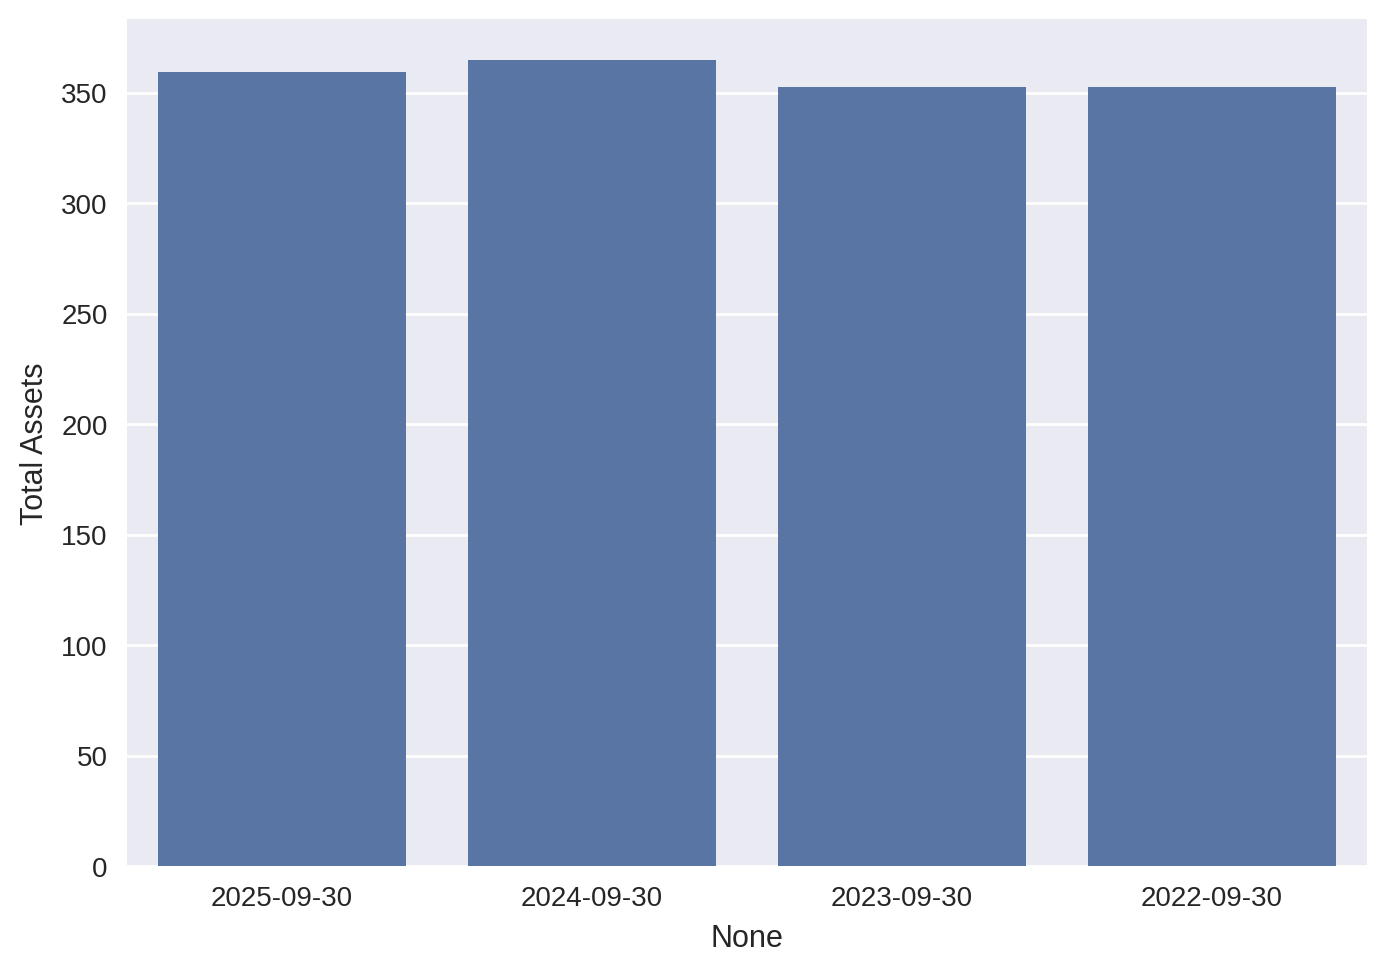

In [260]:
sns.barplot(x = ass_liab_equity.index, y = ass_liab_equity["Total Assets"].div(10**9) )

In [263]:
# 1. Reset index to turn the Date index into a regular column (needed for melting)
df_reset = ass_liab_equity.reset_index()

# 2. Extract just the year from the date column for cleaner X-axis labels
df_reset['Year'] = df_reset['index'].dt.year


# 3. "Melt" the dataframe to go from Wide to Long format
# This creates one column for variable names and one column for values


In [264]:
df_reset

,index,Total Assets,Total Liabilities Net Minority Interest,Total Equity Gross Minority Interest,Year
0,2025-09-30,"359,241,000,000.00","285,508,000,000.00","73,733,000,000.00",2025
1,2024-09-30,"364,980,000,000.00","308,030,000,000.00","56,950,000,000.00",2024
2,2023-09-30,"352,583,000,000.00","290,437,000,000.00","62,146,000,000.00",2023
3,2022-09-30,"352,755,000,000.00","302,083,000,000.00","50,672,000,000.00",2022


In [315]:
df_melt = df_reset.melt(id_vars='Year', value_vars = ["Total Assets", "Total Equity Gross Minority Interest", "Total Liabilities Net Minority Interest"], var_name='Category', value_name='Value')
df_melt["Value"] = df_melt["Value"].div(10**9)
df_melt

,Year,Category,Value
0,2025,Total Assets,359.24
1,2024,Total Assets,364.98
2,2023,Total Assets,352.58
3,2022,Total Assets,352.75
4,2025,Total Equity Gross Minority Interest,73.73
5,2024,Total Equity Gross Minority Interest,56.95
6,2023,Total Equity Gross Minority Interest,62.15
7,2022,Total Equity Gross Minority Interest,50.67
8,2025,Total Liabilities Net Minority Interest,285.51
9,2024,Total Liabilities Net Minority Interest,308.03


In [316]:
df_melt.groupby(["Year", "Category"])["Value"].sum()

Year  Category                               
2022  Total Assets                              352.75
      Total Equity Gross Minority Interest       50.67
      Total Liabilities Net Minority Interest   302.08
2023  Total Assets                              352.58
      Total Equity Gross Minority Interest       62.15
      Total Liabilities Net Minority Interest   290.44
2024  Total Assets                              364.98
      Total Equity Gross Minority Interest       56.95
      Total Liabilities Net Minority Interest   308.03
2025  Total Assets                              359.24
      Total Equity Gross Minority Interest       73.73
      Total Liabilities Net Minority Interest   285.51
Name: Value, dtype: float64

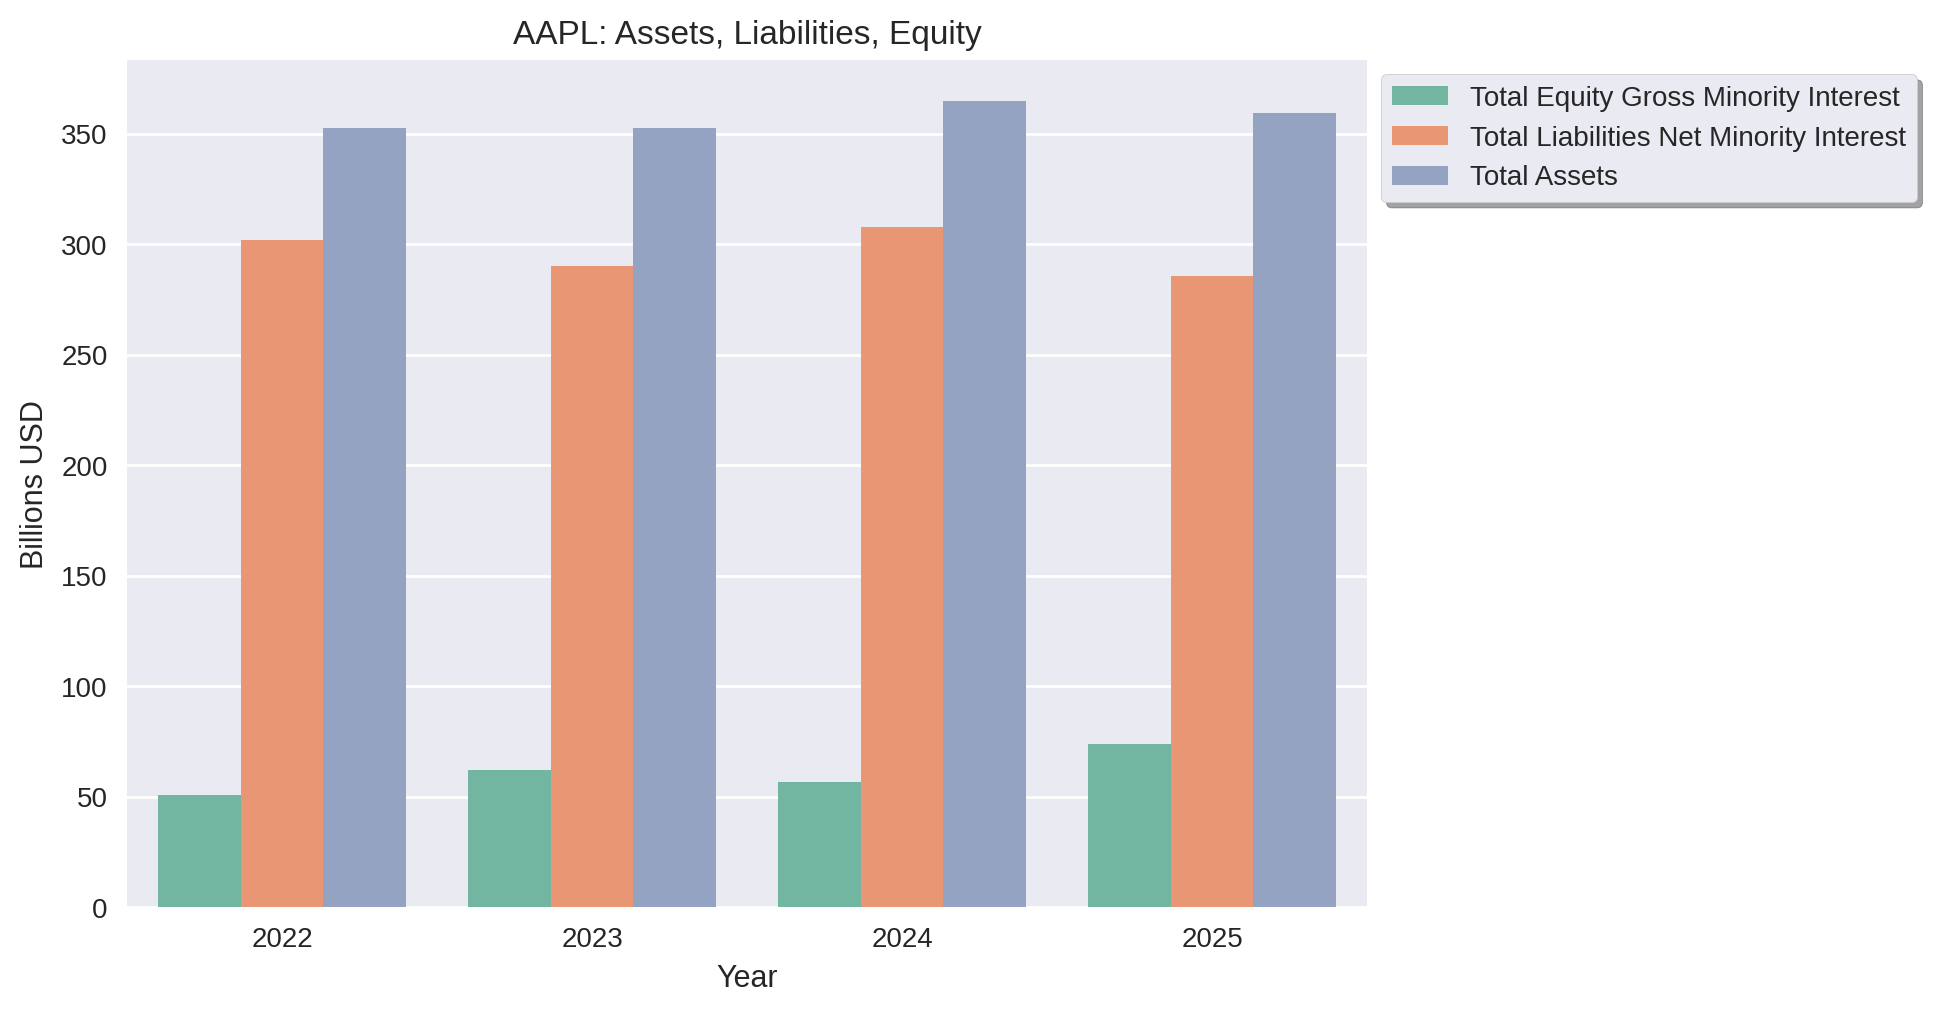

In [317]:
sns.barplot(data = df_melt.sort_values(by = ["Value"], ascending = False)[::-1], x = "Year", y = "Value", hue = "Category", palette = "Set2",legend = True)
plt.title("AAPL: Assets, Liabilities, Equity")
plt.ylabel("Billions USD")
plt.xlabel("Year")
plt.legend(bbox_to_anchor = (1, 1) , fancybox = True, shadow = True, frameon = True)
sns.despine()

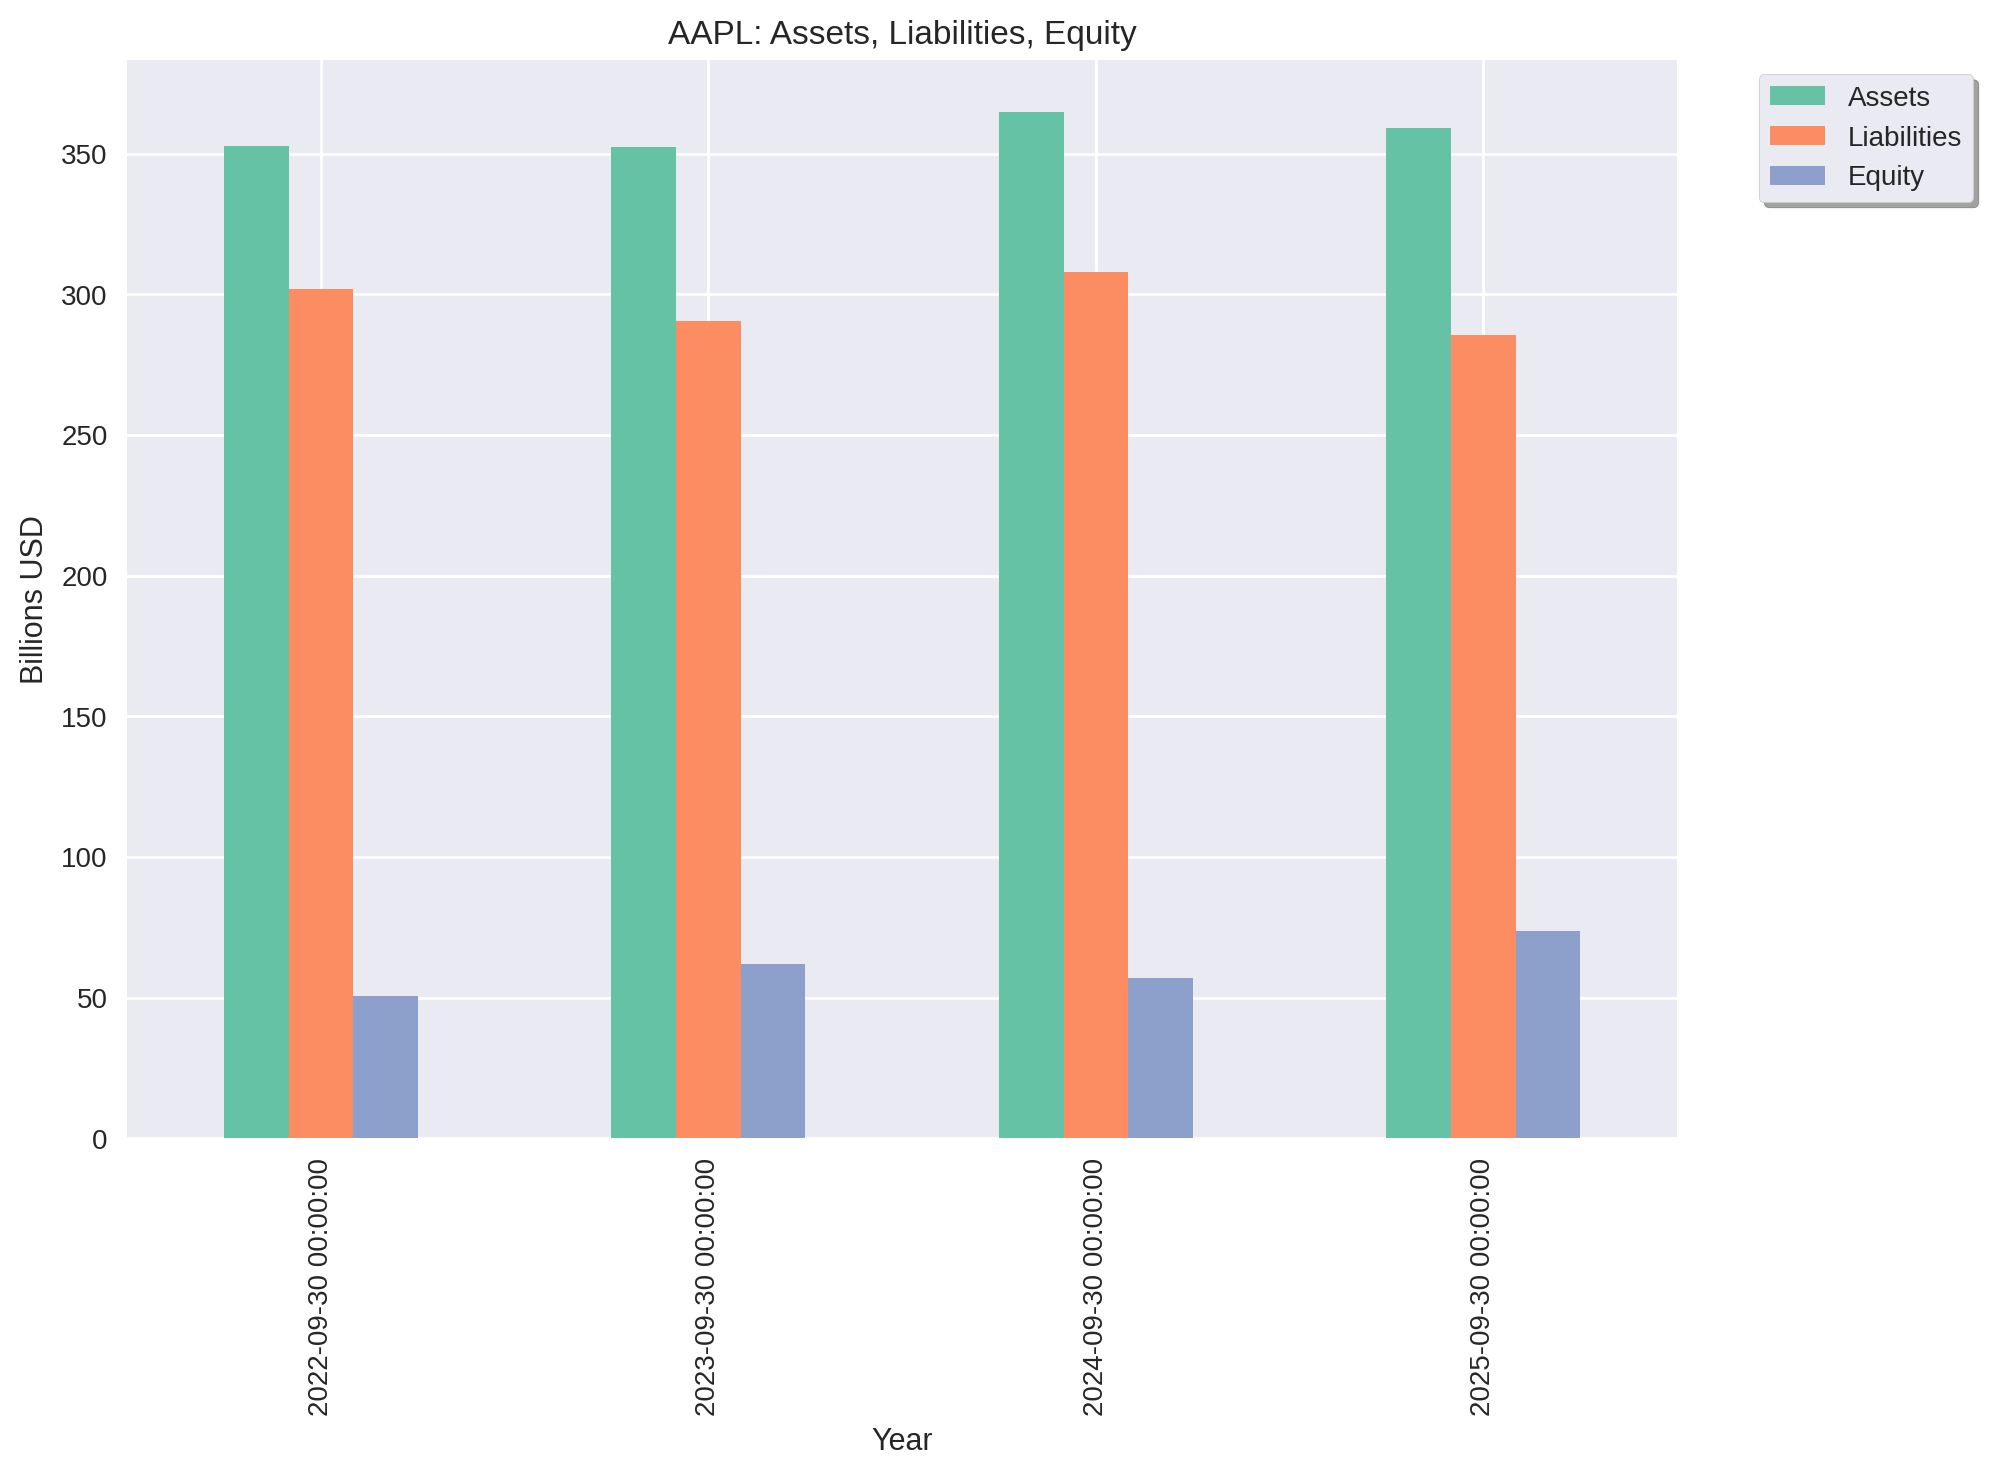

In [308]:
ass_liab_equity.div(10**9)[::-1].plot(kind ="bar" , color = sns.color_palette("Set2"), figsize = (10,7))
#plt.plot(ass_liab_equity.div(10**9).index, ass_liab_equity.div(10**9) , ls = "--", marker = "o", ms = 10)
plt.title("AAPL: Assets, Liabilities, Equity")
plt.ylabel("Billions USD")
plt.xlabel("Year")
#plt.xticks(ticks = list(ass_liab_equity.index.year), labels = list(ass_liab_equity.index.year))
plt.legend(["Assets", "Liabilities", "Equity"] , bbox_to_anchor = (1.2, 1) , fancybox = True, shadow = True, frameon = True)
plt.show()

In [214]:
 ass_liab_equity.columns

Index(['Total Assets', 'Total Liabilities Net Minority Interest',
       'Total Equity Gross Minority Interest'],
      dtype='object')

In [220]:
list(ass_liab_equity.index.year)

[2025, 2024, 2023, 2022]

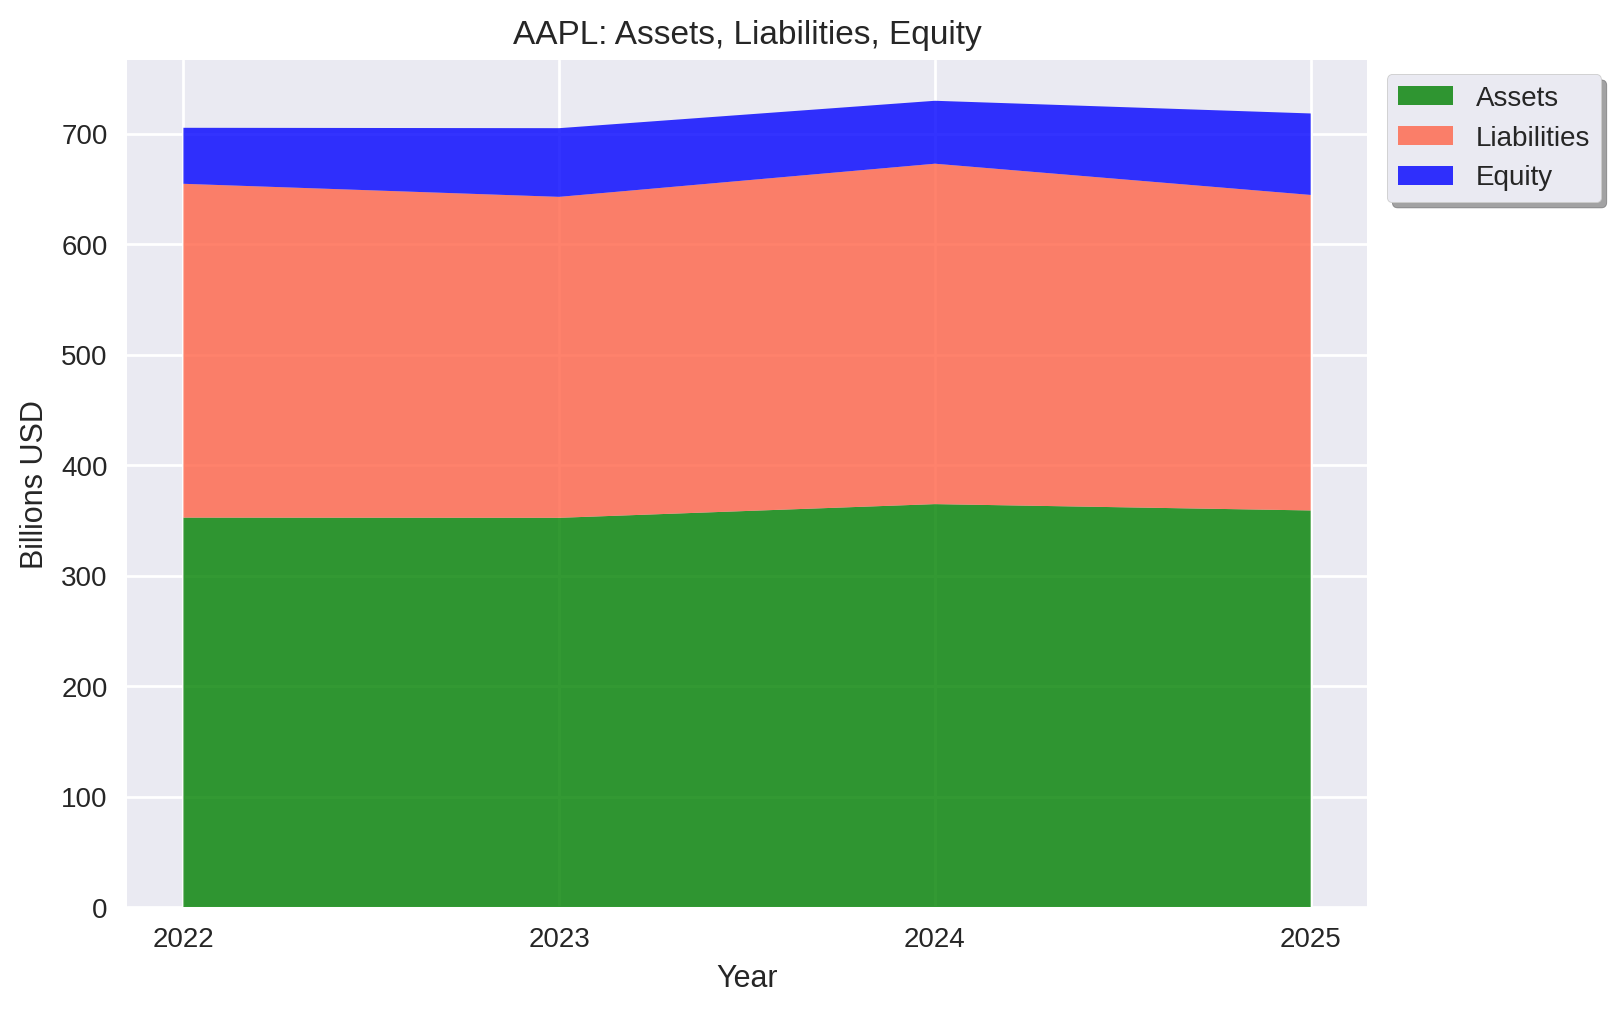

In [300]:
plt.stackplot(list(ass_liab_equity.index.year), 
              ass_liab_equity['Total Assets'].div(10**9),
              ass_liab_equity['Total Liabilities Net Minority Interest'].div(10**9),
              ass_liab_equity['Total Equity Gross Minority Interest'].div(10**9),
              labels = ["Assets","Liabilities" , "Equity"],
              colors = ["green" , "tomato" , "blue"],
              alpha = 0.8
              )
plt.title("AAPL: Assets, Liabilities, Equity")
plt.ylabel("Billions USD")
plt.xlabel("Year")
plt.xticks(ticks = list(ass_liab_equity.index.year), labels = list(ass_liab_equity.index.year))
plt.legend(bbox_to_anchor = (1.2, 1) , fancybox = True, shadow = True, frameon = True)

plt.show()

In [165]:
market_cap = aapl.fast_info["market_cap"]
market_cap

4602870711986.816

In [169]:
equity_to_market_cap = total_equity.iloc[0] / market_cap
equity_to_market_cap

np.float64(0.016018916153344085)

__Low P/B ratio (GM)__

In [318]:
symbol = "GM"

In [319]:
yf.Ticker(ticker = symbol).get_info()["priceToBook"] #yfinance

1.0974995

In [320]:
Ticker(symbol).key_stats[symbol]["priceToBook"] #yahooquery

1.0974995

__Be carefull with any conclusions!__

1. __GM is relatively more attractive than AAPL.__ <br>
-> __No!__ High/Low P/B ratios __may be justified__. Further analysis required!

2. __GM Stock must be undervalued__ and is therefore a clear buy. <br>
-> __No!__ There may be __good reasons__ for low valuation. (low/negative profitability and/or growth) 

3. For GM shareholders it should be more attractive to __cease operations__ and sell all assets (Liquidation). <br>
-> __No!__ Liquidation Value __!=__ Book Value of Assets

P/B ratio should be analyzed together with other ratios/metrics (__not isolated__). <br>
__Factors__ that drive P/B ratios:

- __Profitability__ (+)
- __Growth__ (+)
- __Sector/Industry__ (Service/IT vs. Manufacturing)
- __Asset/Capital Intensity__ (-)
- Operational Business Decisions - e.g. __outsourcing manufacturing__ (+)
- __Off-Balance Sheet Financing__ - e.g. Leasing (+)

__-> Be careful when comparing apples and oranges!__

## Financial Statements

In [321]:
aapl #yfinance

yfinance.Ticker object <AAPL>

In [323]:
aapl_yq #yahooquery

__Balance Sheet__

In [324]:
bs = aapl.get_balance_sheet() / 1000000 # annual (in million USD) yfinance
bs

,2025-09-30,2024-09-30,2023-09-30,2022-09-30,2021-09-30
TreasurySharesNumber,NaN,NaN,0.00,NaN,NaN
OrdinarySharesNumber,"14,773.26","15,116.79","15,550.06","15,943.42",NaN
ShareIssued,"14,773.26","15,116.79","15,550.06","15,943.42",NaN
NetDebt,"62,723.00","76,686.00","81,123.00","96,423.00",NaN
TotalDebt,"98,657.00","106,629.00","111,088.00","132,480.00",NaN
...,...,...,...,...,...
CashCashEquivalentsAndShortTermInvestments,"54,697.00","65,171.00","61,555.00","48,304.00",NaN
OtherShortTermInvestments,"18,763.00","35,228.00","31,590.00","24,658.00",NaN
CashAndCashEquivalents,"35,934.00","29,943.00","29,965.00","23,646.00",NaN
CashEquivalents,"7,667.00","2,744.00","1,606.00","5,100.00",NaN


In [325]:
bs_yq = aapl_yq.balance_sheet().T #yahooquery
bs_yq

symbol,AAPL,AAPL,AAPL,AAPL,AAPL
asOfDate,2021-09-30 00:00:00,2022-09-30 00:00:00,2023-09-30 00:00:00,2024-09-30 00:00:00,2025-09-30 00:00:00
periodType,12M,12M,12M,12M,12M
currencyCode,USD,USD,USD,USD,USD
AccountsPayable,NaN,"64,115,000,000.00","62,611,000,000.00","68,960,000,000.00","69,860,000,000.00"
AccountsReceivable,NaN,"28,184,000,000.00","29,508,000,000.00","33,410,000,000.00","39,777,000,000.00"
...,...,...,...,...,...
TotalNonCurrentLiabilitiesNetMinorityInterest,NaN,"148,101,000,000.00","145,129,000,000.00","131,638,000,000.00","119,877,000,000.00"
TotalTaxPayable,NaN,"6,552,000,000.00","8,819,000,000.00","26,601,000,000.00","13,016,000,000.00"
TradeandOtherPayablesNonCurrent,"24,689,000,000.00","16,657,000,000.00","15,457,000,000.00","9,254,000,000.00",NaN
TreasurySharesNumber,NaN,NaN,0.00,NaN,NaN


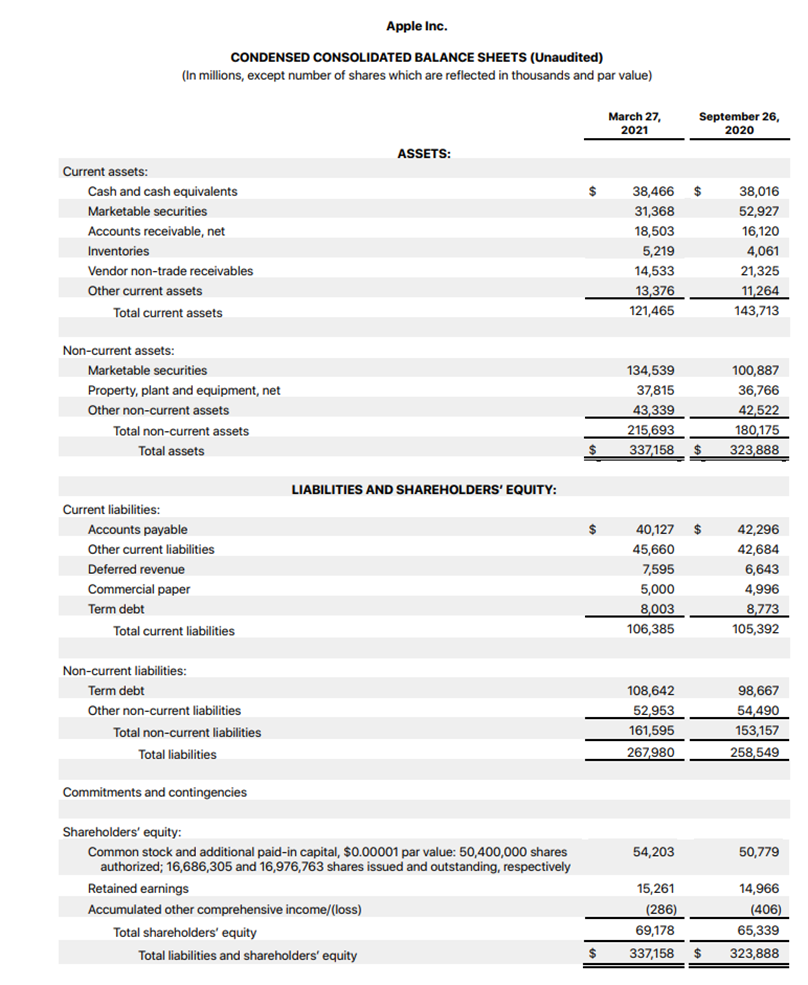

__Income Statement__

In [326]:
inc_stat = aapl.get_income_stmt() / 1000000 # (in million USD) yfinance
inc_stat

,2025-09-30,2024-09-30,2023-09-30,2022-09-30,2021-09-30
TaxEffectOfUnusualItems,0.00,0.00,0.00,0.00,NaN
TaxRateForCalcs,0.00,0.00,0.00,0.00,NaN
NormalizedEBITDA,"144,748.00","134,661.00","125,820.00","130,541.00",NaN
NetIncomeFromContinuingOperationNetMinorityInterest,"112,010.00","93,736.00","96,995.00","99,803.00",NaN
ReconciledDepreciation,"11,698.00","11,445.00","11,519.00","11,104.00",NaN
ReconciledCostOfRevenue,"220,960.00","210,352.00","214,137.00","223,546.00",NaN
EBITDA,"144,748.00","134,661.00","125,820.00","130,541.00",NaN
EBIT,"133,050.00","123,216.00","114,301.00","119,437.00",NaN
NetInterestIncome,NaN,NaN,-183.00,-106.00,198.00
InterestExpense,NaN,NaN,"3,933.00","2,931.00","2,645.00"


In [ ]:
inc_stat_yq = aapl_yq.income_statement().T # yahooquery
inc_stat_yq

symbol,AAPL,AAPL,AAPL,AAPL,AAPL,AAPL,AAPL,AAPL,AAPL,AAPL,AAPL,AAPL,AAPL,AAPL,AAPL,AAPL
asOfDate,2021-09-30 00:00:00,2022-09-30 00:00:00,2023-09-30 00:00:00,2023-09-30 00:00:00,2023-12-31 00:00:00,2024-03-31 00:00:00,2024-06-30 00:00:00,2024-09-30 00:00:00,2024-09-30 00:00:00,2024-12-31 00:00:00,2025-03-31 00:00:00,2025-06-30 00:00:00,2025-09-30 00:00:00,2025-09-30 00:00:00,2025-12-31 00:00:00,2026-03-31 00:00:00
periodType,12M,12M,12M,TTM,TTM,TTM,TTM,12M,TTM,TTM,TTM,TTM,12M,TTM,TTM,TTM
currencyCode,USD,USD,USD,USD,USD,USD,USD,USD,USD,USD,USD,USD,USD,USD,USD,USD
BasicAverageShares,NaN,"16,215,963,000.00","15,744,231,000.00","15,744,231,000.00","15,648,491,000.00","15,553,166,500.00","15,450,643,500.00","15,343,783,000.00","15,343,783,000.00","15,236,773,250.00","15,133,829,500.00","15,037,671,250.00","14,948,500,000.00","14,948,500,000.00","14,865,108,500.00","14,784,907,500.00"
BasicEPS,NaN,6.15,6.16,6.16,6.46,6.46,6.60,6.11,6.11,6.33,6.45,6.62,7.49,7.49,7.93,8.30
CostOfRevenue,NaN,"223,546,000,000.00","214,137,000,000.00",NaN,NaN,NaN,NaN,"210,352,000,000.00",NaN,NaN,NaN,"217,886,000,000.00","220,960,000,000.00",NaN,NaN,"235,371,000,000.00"
DilutedAverageShares,NaN,"16,325,819,000.00","15,812,547,000.00","15,812,547,000.00","15,717,777,750.00","15,622,192,500.00","15,515,481,000.00","15,408,095,000.00","15,408,095,000.00","15,301,651,000.00","15,199,507,000.00","15,099,508,250.00","15,004,697,000.00","15,004,697,000.00","14,919,569,750.00","14,837,005,000.00"
DilutedEPS,NaN,6.11,6.13,6.13,6.43,6.43,6.57,6.08,6.08,6.30,6.42,6.59,7.46,7.46,7.90,8.26
DilutedNIAvailtoComStockholders,NaN,"99,803,000,000.00","96,995,000,000.00",NaN,NaN,NaN,NaN,"93,736,000,000.00",NaN,NaN,NaN,"99,280,000,000.00","112,010,000,000.00",NaN,NaN,"122,575,000,000.00"
EBIT,NaN,"119,437,000,000.00","114,301,000,000.00",NaN,NaN,NaN,NaN,"123,216,000,000.00",NaN,NaN,NaN,"130,214,000,000.00","133,050,000,000.00",NaN,NaN,"147,366,000,000.00"


In [ ]:
inc_stat_yq.loc[["CostOfRevenue","ReconciledCostOfRevenue"]]

symbol,AAPL,AAPL,AAPL,AAPL,AAPL,AAPL,AAPL,AAPL,AAPL,AAPL,AAPL,AAPL,AAPL,AAPL,AAPL,AAPL
CostOfRevenue,NaN,"223,546,000,000.00","214,137,000,000.00",NaN,NaN,NaN,NaN,"210,352,000,000.00",NaN,NaN,NaN,"217,886,000,000.00","220,960,000,000.00",NaN,NaN,"235,371,000,000.00"
ReconciledCostOfRevenue,NaN,"223,546,000,000.00","214,137,000,000.00",NaN,NaN,NaN,NaN,"210,352,000,000.00",NaN,NaN,NaN,"217,886,000,000.00","220,960,000,000.00",NaN,NaN,"235,371,000,000.00"


In [403]:
mask_inc_stat = ["asOfDate",
    'TotalRevenue',
    'CostOfRevenue',
    'GrossProfit',
    'ResearchAndDevelopment',
    'SellingGeneralAndAdministration',
    'OperatingExpense',
    'OperatingIncome',
    'OtherIncomeExpense',
    'PretaxIncome',
    'TaxProvision',
    'NetIncome'
]

In [418]:
list(range(16))

[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15]

In [419]:
trimmed_inc_stat_yq = inc_stat_yq.loc[mask_inc_stat]
#trimmed_inc_stat_yq.drop(columns = [0 , 3 , 4 , 5 ,6 , 8 , 9 , 10 , 13 , 14])
trimmed_inc_stat_yq.columns = list(range(16))
trimmed_inc_stat_yq

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15
asOfDate,2021-09-30 00:00:00,2022-09-30 00:00:00,2023-09-30 00:00:00,2023-09-30 00:00:00,2023-12-31 00:00:00,2024-03-31 00:00:00,2024-06-30 00:00:00,2024-09-30 00:00:00,2024-09-30 00:00:00,2024-12-31 00:00:00,2025-03-31 00:00:00,2025-06-30 00:00:00,2025-09-30 00:00:00,2025-09-30 00:00:00,2025-12-31 00:00:00,2026-03-31 00:00:00
TotalRevenue,NaN,"394,328,000,000.00","383,285,000,000.00",NaN,NaN,NaN,NaN,"391,035,000,000.00",NaN,NaN,NaN,"408,625,000,000.00","416,161,000,000.00",NaN,NaN,"451,442,000,000.00"
CostOfRevenue,NaN,"223,546,000,000.00","214,137,000,000.00",NaN,NaN,NaN,NaN,"210,352,000,000.00",NaN,NaN,NaN,"217,886,000,000.00","220,960,000,000.00",NaN,NaN,"235,371,000,000.00"
GrossProfit,NaN,"170,782,000,000.00","169,148,000,000.00",NaN,NaN,NaN,NaN,"180,683,000,000.00",NaN,NaN,NaN,"190,739,000,000.00","195,201,000,000.00",NaN,NaN,"216,071,000,000.00"
ResearchAndDevelopment,NaN,"26,251,000,000.00","29,915,000,000.00",NaN,NaN,NaN,NaN,"31,370,000,000.00",NaN,NaN,NaN,"33,449,000,000.00","34,550,000,000.00",NaN,NaN,"40,038,000,000.00"
SellingGeneralAndAdministration,NaN,"25,094,000,000.00","24,932,000,000.00",NaN,NaN,NaN,NaN,"26,097,000,000.00",NaN,NaN,NaN,"27,076,000,000.00","27,601,000,000.00",NaN,NaN,"28,667,000,000.00"
OperatingExpense,NaN,"51,345,000,000.00","54,847,000,000.00",NaN,NaN,NaN,NaN,"57,467,000,000.00",NaN,NaN,NaN,"60,525,000,000.00","62,151,000,000.00",NaN,NaN,"68,705,000,000.00"
OperatingIncome,NaN,"119,437,000,000.00","114,301,000,000.00",NaN,NaN,NaN,NaN,"123,216,000,000.00",NaN,NaN,NaN,"130,214,000,000.00","133,050,000,000.00",NaN,NaN,"147,366,000,000.00"
OtherIncomeExpense,NaN,"-334,000,000.00","-565,000,000.00",NaN,NaN,NaN,NaN,"269,000,000.00",NaN,NaN,NaN,"-679,000,000.00","-321,000,000.00",NaN,NaN,"304,000,000.00"
PretaxIncome,NaN,"119,103,000,000.00","113,736,000,000.00",NaN,NaN,NaN,NaN,"123,485,000,000.00",NaN,NaN,NaN,"129,535,000,000.00","132,729,000,000.00",NaN,NaN,"147,670,000,000.00"


In [420]:
trimmed_inc_stat_yq.drop(columns = [0 , 3 , 4 , 5 ,6 , 8 , 9 , 10 , 13 , 14])

,1,2,7,11,12,15
asOfDate,2022-09-30 00:00:00,2023-09-30 00:00:00,2024-09-30 00:00:00,2025-06-30 00:00:00,2025-09-30 00:00:00,2026-03-31 00:00:00
TotalRevenue,"394,328,000,000.00","383,285,000,000.00","391,035,000,000.00","408,625,000,000.00","416,161,000,000.00","451,442,000,000.00"
CostOfRevenue,"223,546,000,000.00","214,137,000,000.00","210,352,000,000.00","217,886,000,000.00","220,960,000,000.00","235,371,000,000.00"
GrossProfit,"170,782,000,000.00","169,148,000,000.00","180,683,000,000.00","190,739,000,000.00","195,201,000,000.00","216,071,000,000.00"
ResearchAndDevelopment,"26,251,000,000.00","29,915,000,000.00","31,370,000,000.00","33,449,000,000.00","34,550,000,000.00","40,038,000,000.00"
SellingGeneralAndAdministration,"25,094,000,000.00","24,932,000,000.00","26,097,000,000.00","27,076,000,000.00","27,601,000,000.00","28,667,000,000.00"
OperatingExpense,"51,345,000,000.00","54,847,000,000.00","57,467,000,000.00","60,525,000,000.00","62,151,000,000.00","68,705,000,000.00"
OperatingIncome,"119,437,000,000.00","114,301,000,000.00","123,216,000,000.00","130,214,000,000.00","133,050,000,000.00","147,366,000,000.00"
OtherIncomeExpense,"-334,000,000.00","-565,000,000.00","269,000,000.00","-679,000,000.00","-321,000,000.00","304,000,000.00"
PretaxIncome,"119,103,000,000.00","113,736,000,000.00","123,485,000,000.00","129,535,000,000.00","132,729,000,000.00","147,670,000,000.00"


In [421]:
trimmed_inc_stat_yq = trimmed_inc_stat_yq.drop(columns = [0 , 3 , 4 , 5 ,6 , 8 , 9 , 10 , 13 , 14])
trimmed_inc_stat_yq

,1,2,7,11,12,15
asOfDate,2022-09-30 00:00:00,2023-09-30 00:00:00,2024-09-30 00:00:00,2025-06-30 00:00:00,2025-09-30 00:00:00,2026-03-31 00:00:00
TotalRevenue,"394,328,000,000.00","383,285,000,000.00","391,035,000,000.00","408,625,000,000.00","416,161,000,000.00","451,442,000,000.00"
CostOfRevenue,"223,546,000,000.00","214,137,000,000.00","210,352,000,000.00","217,886,000,000.00","220,960,000,000.00","235,371,000,000.00"
GrossProfit,"170,782,000,000.00","169,148,000,000.00","180,683,000,000.00","190,739,000,000.00","195,201,000,000.00","216,071,000,000.00"
ResearchAndDevelopment,"26,251,000,000.00","29,915,000,000.00","31,370,000,000.00","33,449,000,000.00","34,550,000,000.00","40,038,000,000.00"
SellingGeneralAndAdministration,"25,094,000,000.00","24,932,000,000.00","26,097,000,000.00","27,076,000,000.00","27,601,000,000.00","28,667,000,000.00"
OperatingExpense,"51,345,000,000.00","54,847,000,000.00","57,467,000,000.00","60,525,000,000.00","62,151,000,000.00","68,705,000,000.00"
OperatingIncome,"119,437,000,000.00","114,301,000,000.00","123,216,000,000.00","130,214,000,000.00","133,050,000,000.00","147,366,000,000.00"
OtherIncomeExpense,"-334,000,000.00","-565,000,000.00","269,000,000.00","-679,000,000.00","-321,000,000.00","304,000,000.00"
PretaxIncome,"119,103,000,000.00","113,736,000,000.00","123,485,000,000.00","129,535,000,000.00","132,729,000,000.00","147,670,000,000.00"


In [422]:
[t.strftime("%Y-%m-%d") for t in trimmed_inc_stat_yq.iloc[0]]

['2022-09-30',
 '2023-09-30',
 '2024-09-30',
 '2025-06-30',
 '2025-09-30',
 '2026-03-31']

In [423]:
trimmed_inc_stat_yq.columns = [t.strftime("%Y-%m-%d") for t in trimmed_inc_stat_yq.iloc[0]]
trimmed_inc_stat_yq

,2022-09-30,2023-09-30,2024-09-30,2025-06-30,2025-09-30,2026-03-31
asOfDate,2022-09-30 00:00:00,2023-09-30 00:00:00,2024-09-30 00:00:00,2025-06-30 00:00:00,2025-09-30 00:00:00,2026-03-31 00:00:00
TotalRevenue,"394,328,000,000.00","383,285,000,000.00","391,035,000,000.00","408,625,000,000.00","416,161,000,000.00","451,442,000,000.00"
CostOfRevenue,"223,546,000,000.00","214,137,000,000.00","210,352,000,000.00","217,886,000,000.00","220,960,000,000.00","235,371,000,000.00"
GrossProfit,"170,782,000,000.00","169,148,000,000.00","180,683,000,000.00","190,739,000,000.00","195,201,000,000.00","216,071,000,000.00"
ResearchAndDevelopment,"26,251,000,000.00","29,915,000,000.00","31,370,000,000.00","33,449,000,000.00","34,550,000,000.00","40,038,000,000.00"
SellingGeneralAndAdministration,"25,094,000,000.00","24,932,000,000.00","26,097,000,000.00","27,076,000,000.00","27,601,000,000.00","28,667,000,000.00"
OperatingExpense,"51,345,000,000.00","54,847,000,000.00","57,467,000,000.00","60,525,000,000.00","62,151,000,000.00","68,705,000,000.00"
OperatingIncome,"119,437,000,000.00","114,301,000,000.00","123,216,000,000.00","130,214,000,000.00","133,050,000,000.00","147,366,000,000.00"
OtherIncomeExpense,"-334,000,000.00","-565,000,000.00","269,000,000.00","-679,000,000.00","-321,000,000.00","304,000,000.00"
PretaxIncome,"119,103,000,000.00","113,736,000,000.00","123,485,000,000.00","129,535,000,000.00","132,729,000,000.00","147,670,000,000.00"


In [424]:
trimmed_inc_stat_yq = trimmed_inc_stat_yq.drop(labels = ["asOfDate"], axis = 0)

In [431]:
trimmed_inc_stat_yq = trimmed_inc_stat_yq.div(10**6)

In [ ]:
trimmed_inc_stat_yq

,2022-09-30,2023-09-30,2024-09-30,2025-06-30,2025-09-30,2026-03-31
TotalRevenue,"394,328.00","383,285.00","391,035.00","408,625.00","416,161.00","451,442.00"
CostOfRevenue,"223,546.00","214,137.00","210,352.00","217,886.00","220,960.00","235,371.00"
GrossProfit,"170,782.00","169,148.00","180,683.00","190,739.00","195,201.00","216,071.00"
ResearchAndDevelopment,"26,251.00","29,915.00","31,370.00","33,449.00","34,550.00","40,038.00"
SellingGeneralAndAdministration,"25,094.00","24,932.00","26,097.00","27,076.00","27,601.00","28,667.00"
OperatingExpense,"51,345.00","54,847.00","57,467.00","60,525.00","62,151.00","68,705.00"
OperatingIncome,"119,437.00","114,301.00","123,216.00","130,214.00","133,050.00","147,366.00"
OtherIncomeExpense,-334.00,-565.00,269.00,-679.00,-321.00,304.00
PretaxIncome,"119,103.00","113,736.00","123,485.00","129,535.00","132,729.00","147,670.00"
TaxProvision,"19,300.00","16,741.00","29,749.00","30,255.00","20,719.00","25,095.00"


In [441]:
trimmed_inc_stat_yq.index

Index(['TotalRevenue', 'CostOfRevenue', 'GrossProfit',
       'ResearchAndDevelopment', 'SellingGeneralAndAdministration',
       'OperatingExpense', 'OperatingIncome', 'OtherIncomeExpense',
       'PretaxIncome', 'TaxProvision', 'NetIncome'],
      dtype='object')

In [445]:
trimmed_inc_stat_yq.index = ['Total_Revenue', 'Cost_Of_Revenue', 'Gross_Profit',
       'R&D', 'SG&A', 'Operating_Expense', 'Operating_Income', 'Other_Income_Expense',
       'Pre_tax_Income', 'Tax_Provision', 'Net_Income']

In [446]:
trimmed_inc_stat_yq.index

Index(['Total_Revenue', 'Cost_Of_Revenue', 'Gross_Profit', 'R&D', 'SG&A',
       'Operating_Expense', 'Operating_Income', 'Other_Income_Expense',
       'Pre_tax_Income', 'Tax_Provision', 'Net_Income'],
      dtype='object')

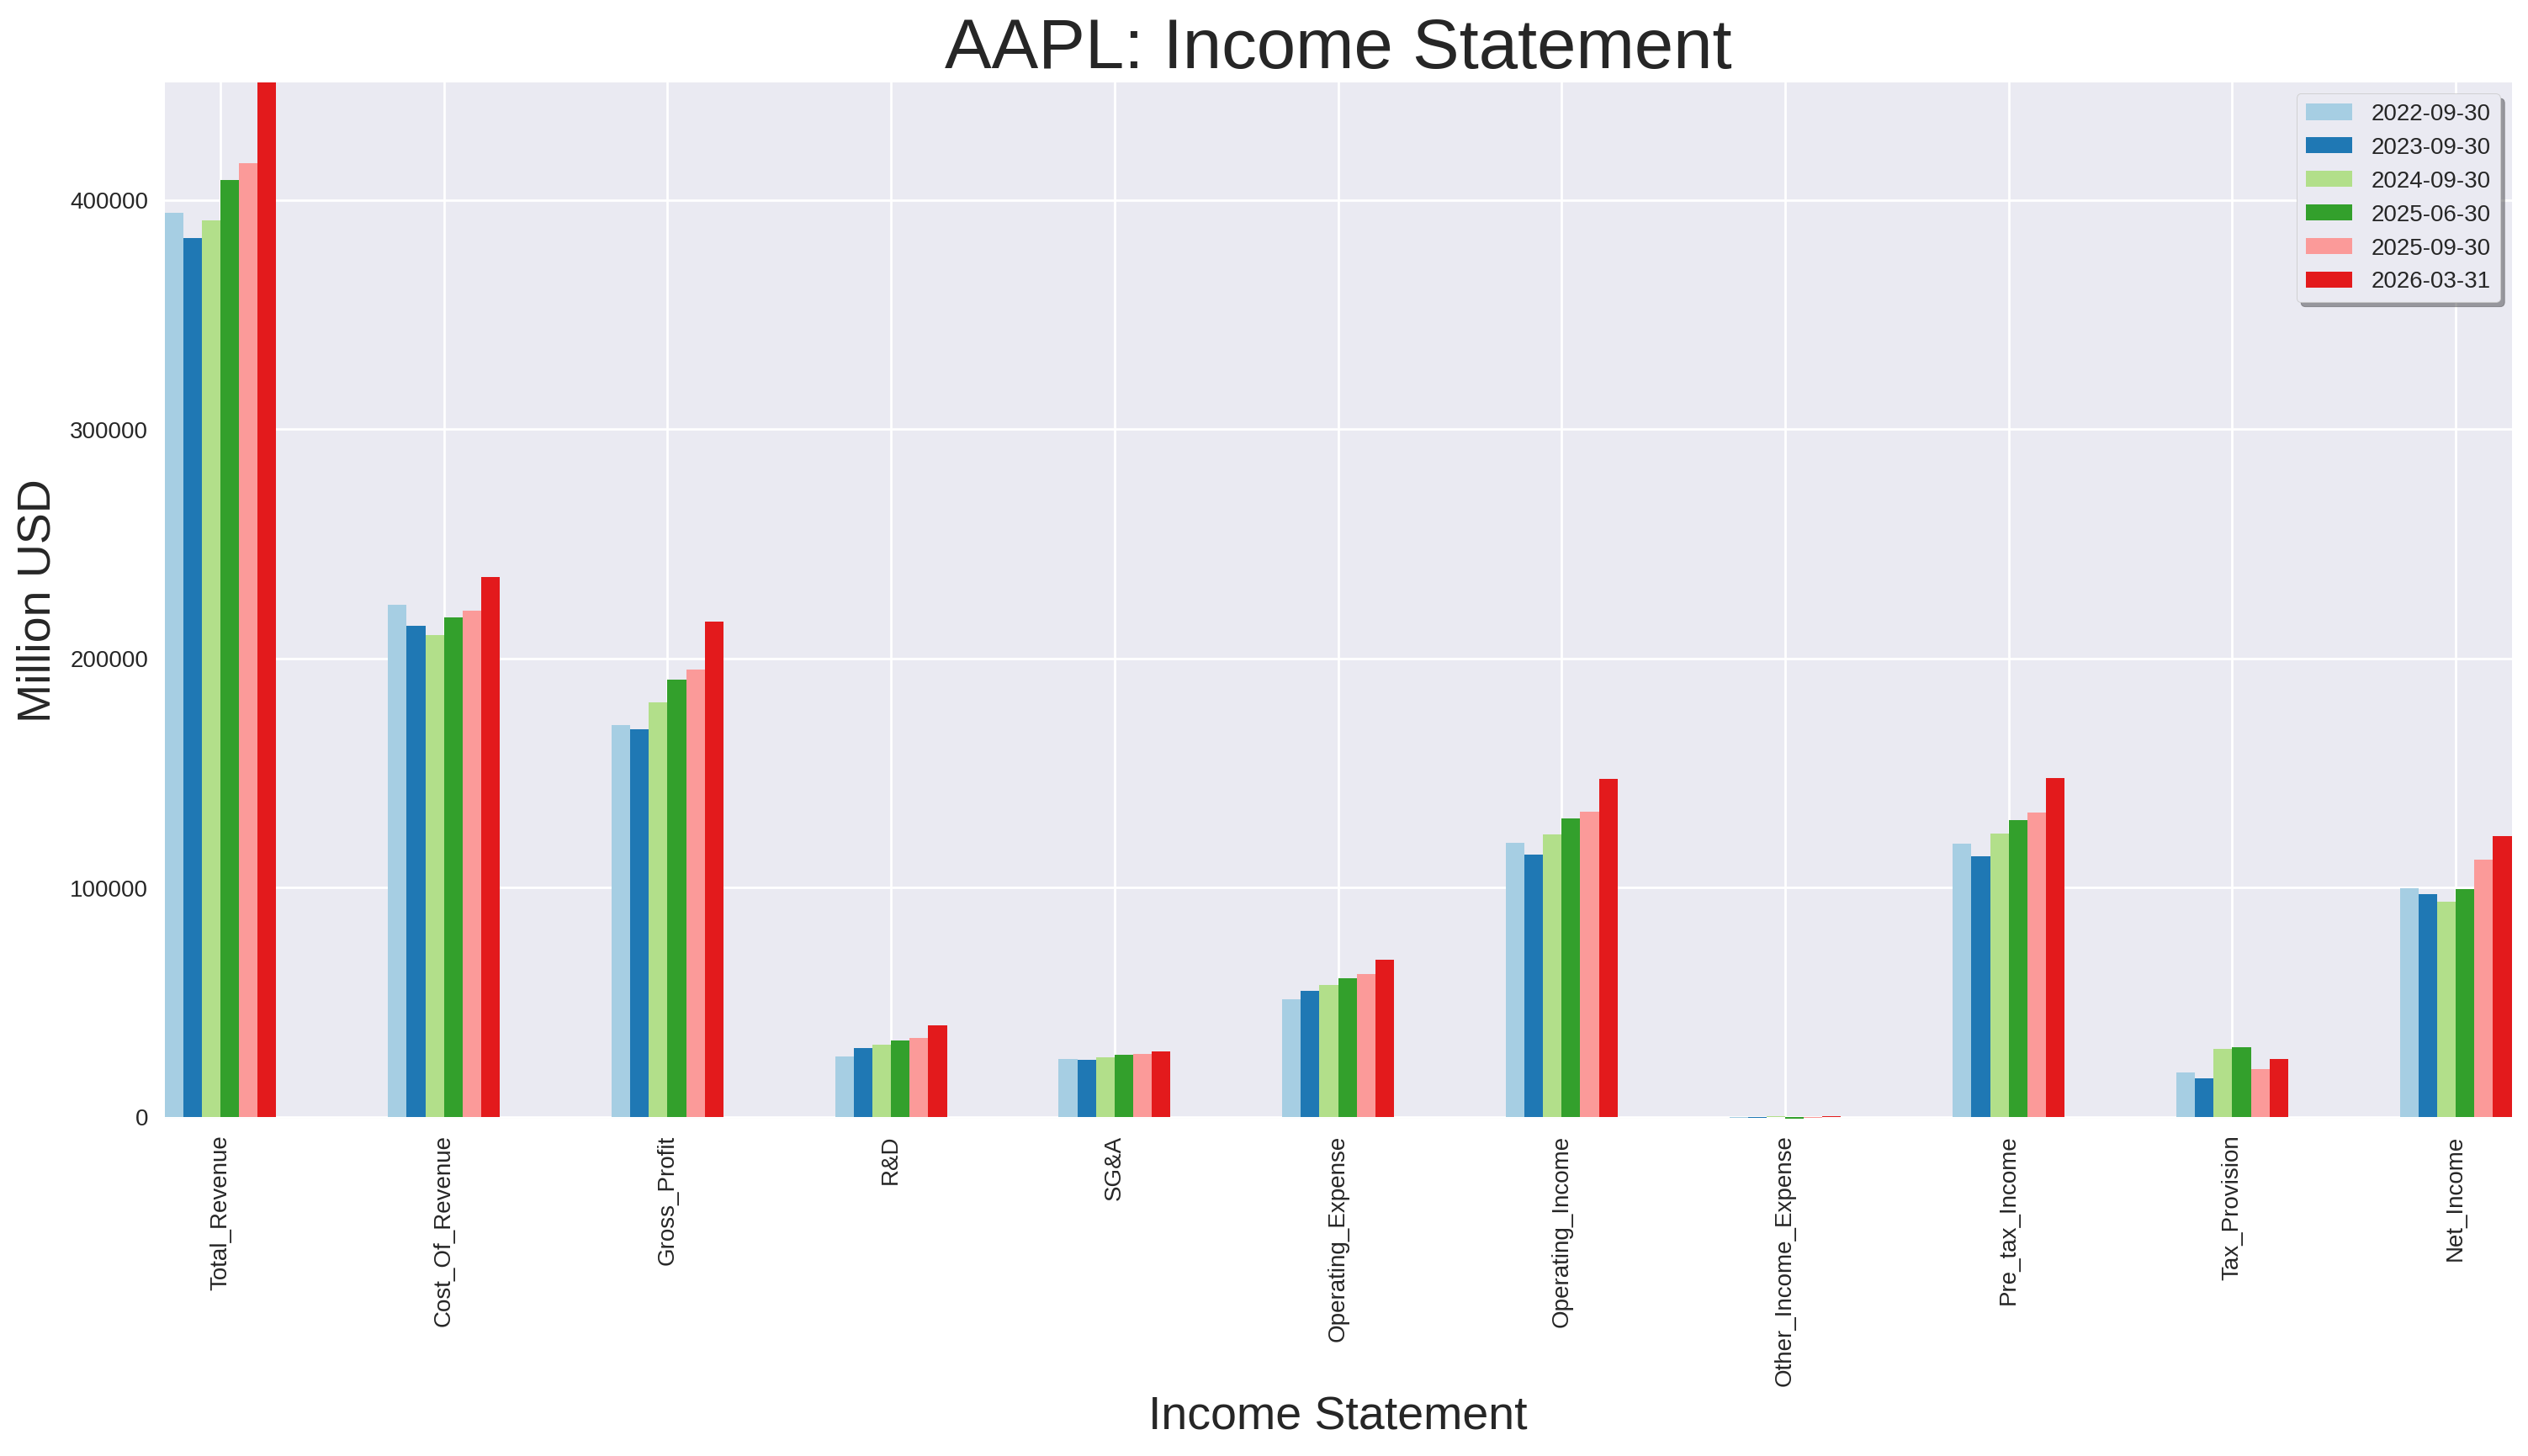

In [467]:
trimmed_inc_stat_yq.plot(kind ="bar" , color = sns.color_palette("Paired"), figsize = (18,8))

plt.title("AAPL: Income Statement" , fontsize = 30)
plt.xlabel("Income Statement" , fontsize = 20)
plt.ylabel("Million USD" , fontsize = 20)

plt.legend(bbox_to_anchor = (1, 1) , fancybox = True, shadow = True, frameon = True)
plt.autoscale(axis = "both" , tight = True)
sns.despine()

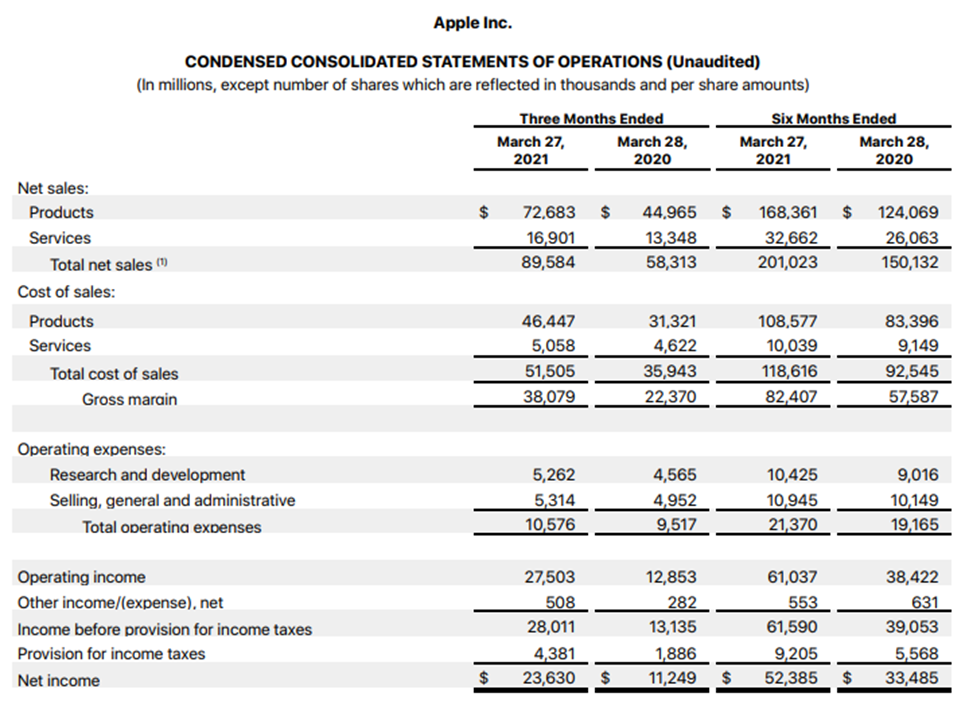

__Cashflow Statement__

In [330]:
cf = aapl.get_cashflow() / 1000000 # (in million USD) #yfinance
cf

,2025-09-30,2024-09-30,2023-09-30,2022-09-30,2021-09-30
FreeCashFlow,"98,767.00","108,807.00","99,584.00","111,443.00",NaN
RepurchaseOfCapitalStock,"-90,711.00","-94,949.00","-77,550.00","-89,402.00",NaN
RepaymentOfDebt,"-10,932.00","-9,958.00","-11,151.00","-9,543.00",NaN
IssuanceOfDebt,"4,481.00",0.00,"5,228.00","5,465.00",NaN
IssuanceOfCapitalStock,NaN,NaN,NaN,NaN,"1,105.00"
CapitalExpenditure,"-12,715.00","-9,447.00","-10,959.00","-10,708.00",NaN
InterestPaidSupplementalData,NaN,NaN,"3,803.00","2,865.00","2,687.00"
IncomeTaxPaidSupplementalData,"43,369.00","26,102.00","18,679.00","19,573.00",NaN
EndCashPosition,"35,934.00","29,943.00","30,737.00","24,977.00",NaN
BeginningCashPosition,"29,943.00","30,737.00","24,977.00","35,929.00",NaN


In [331]:
cf_yq = aapl_yq.cash_flow().T #yahooquery
cf_yq

symbol,AAPL,AAPL,AAPL,AAPL,AAPL,AAPL,AAPL
asOfDate,2021-09-30 00:00:00,2022-09-30 00:00:00,2023-09-30 00:00:00,2024-09-30 00:00:00,2025-06-30 00:00:00,2025-09-30 00:00:00,2026-03-31 00:00:00
periodType,12M,12M,12M,12M,TTM,12M,TTM
currencyCode,USD,USD,USD,USD,USD,USD,USD
BeginningCashPosition,NaN,"35,929,000,000.00","24,977,000,000.00","30,737,000,000.00","26,635,000,000.00","29,943,000,000.00","28,162,000,000.00"
CapitalExpenditure,NaN,"-10,708,000,000.00","-10,959,000,000.00","-9,447,000,000.00","-12,381,000,000.00","-12,715,000,000.00","-11,048,000,000.00"
CashDividendsPaid,NaN,"-14,841,000,000.00","-15,025,000,000.00","-15,234,000,000.00","-15,363,000,000.00","-15,421,000,000.00","-15,550,000,000.00"
CashFlowFromContinuingFinancingActivities,NaN,"-110,749,000,000.00","-108,488,000,000.00","-121,983,000,000.00","-118,158,000,000.00","-120,686,000,000.00","-114,244,000,000.00"
CashFlowFromContinuingInvestingActivities,NaN,"-22,354,000,000.00","3,705,000,000.00","2,935,000,000.00","19,227,000,000.00","15,195,000,000.00","-8,568,000,000.00"
CashFlowFromContinuingOperatingActivities,NaN,"122,151,000,000.00","110,543,000,000.00","118,254,000,000.00","108,565,000,000.00","111,482,000,000.00","140,222,000,000.00"
ChangeInAccountPayable,NaN,"9,448,000,000.00","-1,889,000,000.00","6,020,000,000.00","2,712,000,000.00","902,000,000.00","3,209,000,000.00"


__Quarterly Statements__

In [332]:
aapl.quarterly_balance_sheet #yfinance

,2026-03-31,2025-12-31,2025-09-30,2025-06-30,2025-03-31,2024-12-31
Ordinary Shares Number,"14,667,688,000.00","14,697,926,000.00","14,773,260,000.00","14,856,722,000.00","14,939,315,000.00",NaN
Share Issued,"14,667,688,000.00","14,697,926,000.00","14,773,260,000.00","14,856,722,000.00","14,939,315,000.00",NaN
Net Debt,"39,139,000,000.00","45,192,000,000.00","62,723,000,000.00","65,429,000,000.00","70,024,000,000.00",NaN
Total Debt,"84,711,000,000.00","90,509,000,000.00","98,657,000,000.00","101,698,000,000.00","98,186,000,000.00",NaN
Tangible Book Value,"85,157,000,000.00","88,190,000,000.00","73,733,000,000.00","65,830,000,000.00","66,796,000,000.00",NaN
...,...,...,...,...,...,...
Cash Cash Equivalents And Short Term Investments,"68,507,000,000.00","66,907,000,000.00","54,697,000,000.00","55,372,000,000.00","48,498,000,000.00",NaN
Other Short Term Investments,"22,935,000,000.00","21,590,000,000.00","18,763,000,000.00","19,103,000,000.00","20,336,000,000.00",NaN
Cash And Cash Equivalents,"45,572,000,000.00","45,317,000,000.00","35,934,000,000.00","36,269,000,000.00","28,162,000,000.00",NaN
Cash Equivalents,"15,832,000,000.00","14,491,000,000.00","7,667,000,000.00","9,583,000,000.00","3,101,000,000.00",NaN


In [333]:
aapl.quarterly_income_stmt #yfinance

,2026-03-31,2025-12-31,2025-09-30,2025-06-30,2025-03-31
Tax Effect Of Unusual Items,0.00,0.00,0.00,0.00,0.00
Tax Rate For Calcs,0.17,0.17,0.16,0.16,0.15
Normalized EBITDA,"39,324,000,000.00","54,066,000,000.00","35,554,000,000.00","31,032,000,000.00","32,250,000,000.00"
Net Income From Continuing Operation Net Minority Interest,"29,578,000,000.00","42,097,000,000.00","27,466,000,000.00","23,434,000,000.00","24,780,000,000.00"
Reconciled Depreciation,"3,439,000,000.00","3,214,000,000.00","3,127,000,000.00","2,830,000,000.00","2,661,000,000.00"
Reconciled Cost Of Revenue,"56,403,000,000.00","74,525,000,000.00","54,125,000,000.00","50,318,000,000.00","50,492,000,000.00"
EBITDA,"39,324,000,000.00","54,066,000,000.00","35,554,000,000.00","31,032,000,000.00","32,250,000,000.00"
EBIT,"35,885,000,000.00","50,852,000,000.00","32,427,000,000.00","28,202,000,000.00","29,589,000,000.00"
Normalized Income,"29,578,000,000.00","42,097,000,000.00","27,466,000,000.00","23,434,000,000.00","24,780,000,000.00"
Net Income From Continuing And Discontinued Operation,"29,578,000,000.00","42,097,000,000.00","27,466,000,000.00","23,434,000,000.00","24,780,000,000.00"


In [334]:
aapl.quarterly_cashflow #yfinance

,2026-03-31,2025-12-31,2025-09-30,2025-06-30,2025-03-31,2024-12-31
Free Cash Flow,"26,731,000,000.00","51,552,000,000.00","26,486,000,000.00","24,405,000,000.00","20,881,000,000.00",NaN
Repurchase Of Capital Stock,"-12,288,000,000.00","-24,701,000,000.00","-20,132,000,000.00","-21,075,000,000.00","-25,898,000,000.00",NaN
Repayment Of Debt,"-5,751,000,000.00","-8,074,000,000.00","-1,185,000,000.00","-1,770,000,000.00","976,000,000.00",NaN
Issuance Of Debt,NaN,NaN,0.00,NaN,NaN,NaN
Capital Expenditure,"-1,971,000,000.00","-2,373,000,000.00","-3,242,000,000.00","-3,462,000,000.00","-3,071,000,000.00",NaN
Income Tax Paid Supplemental Data,"16,963,000,000.00","3,434,000,000.00","6,037,000,000.00","5,649,000,000.00","13,032,000,000.00",NaN
End Cash Position,"45,572,000,000.00","45,317,000,000.00","35,934,000,000.00","36,269,000,000.00","28,162,000,000.00",NaN
Beginning Cash Position,"45,317,000,000.00","35,934,000,000.00","36,269,000,000.00","28,162,000,000.00","30,299,000,000.00",NaN
Changes In Cash,"255,000,000.00","9,383,000,000.00","-335,000,000.00","8,107,000,000.00","-2,137,000,000.00",NaN
Financing Cash Flow,"-22,279,000,000.00","-39,656,000,000.00","-27,476,000,000.00","-24,833,000,000.00","-29,006,000,000.00",NaN


In [335]:
aapl_yq.balance_sheet(frequency = "q").T #yahooquery

symbol,AAPL,AAPL,AAPL,AAPL,AAPL,AAPL
asOfDate,2024-12-31 00:00:00,2025-03-31 00:00:00,2025-06-30 00:00:00,2025-09-30 00:00:00,2025-12-31 00:00:00,2026-03-31 00:00:00
periodType,3M,3M,3M,3M,3M,3M
currencyCode,USD,USD,USD,USD,USD,USD
AccountsPayable,NaN,"54,126,000,000.00","50,374,000,000.00","69,860,000,000.00","70,587,000,000.00","57,349,000,000.00"
AccountsReceivable,NaN,"26,136,000,000.00","27,557,000,000.00","39,777,000,000.00","39,921,000,000.00","30,339,000,000.00"
...,...,...,...,...,...,...
TotalLiabilitiesNetMinorityInterest,NaN,"264,437,000,000.00","265,665,000,000.00","285,508,000,000.00","291,107,000,000.00","264,591,000,000.00"
TotalNonCurrentAssets,NaN,"212,559,000,000.00","209,004,000,000.00","211,284,000,000.00","221,193,000,000.00","226,968,000,000.00"
TotalNonCurrentLiabilitiesNetMinorityInterest,NaN,"119,866,000,000.00","124,545,000,000.00","119,877,000,000.00","128,740,000,000.00","129,950,000,000.00"
TotalTaxPayable,NaN,NaN,NaN,"13,016,000,000.00",NaN,NaN


In [336]:
aapl_yq.income_statement(frequency = "q").T #yahooquery

symbol,AAPL,AAPL,AAPL,AAPL,AAPL,AAPL,AAPL,AAPL,AAPL,AAPL,AAPL,AAPL,AAPL,AAPL,AAPL,AAPL
asOfDate,2023-09-30 00:00:00,2023-12-31 00:00:00,2024-03-31 00:00:00,2024-06-30 00:00:00,2024-09-30 00:00:00,2024-12-31 00:00:00,2025-03-31 00:00:00,2025-03-31 00:00:00,2025-06-30 00:00:00,2025-06-30 00:00:00,2025-09-30 00:00:00,2025-09-30 00:00:00,2025-12-31 00:00:00,2025-12-31 00:00:00,2026-03-31 00:00:00,2026-03-31 00:00:00
periodType,TTM,TTM,TTM,TTM,TTM,TTM,3M,TTM,3M,TTM,3M,TTM,3M,TTM,3M,TTM
currencyCode,USD,USD,USD,USD,USD,USD,USD,USD,USD,USD,USD,USD,USD,USD,USD,USD
BasicAverageShares,"15,744,231,000.00","15,648,491,000.00","15,553,166,500.00","15,450,643,500.00","15,343,783,000.00","15,236,773,250.00","14,994,082,000.00","15,133,829,500.00","14,902,886,000.00","15,037,671,250.00","14,815,307,000.00","14,948,500,000.00","14,748,158,000.00","14,865,108,500.00","14,673,278,000.00","14,784,907,500.00"
BasicEPS,6.16,6.46,6.46,6.60,6.11,6.33,1.65,6.45,1.57,6.62,1.85,7.49,2.85,7.93,2.02,8.30
CostOfRevenue,NaN,NaN,NaN,NaN,NaN,NaN,"50,492,000,000.00",NaN,"50,318,000,000.00","217,886,000,000.00","54,125,000,000.00",NaN,"74,525,000,000.00",NaN,"56,403,000,000.00","235,371,000,000.00"
DilutedAverageShares,"15,812,547,000.00","15,717,777,750.00","15,622,192,500.00","15,515,481,000.00","15,408,095,000.00","15,301,651,000.00","15,056,133,000.00","15,199,507,000.00","14,948,179,000.00","15,099,508,250.00","14,863,609,000.00","15,004,697,000.00","14,810,356,000.00","14,919,569,750.00","14,725,873,000.00","14,837,005,000.00"
DilutedEPS,6.13,6.43,6.43,6.57,6.08,6.30,1.65,6.42,1.57,6.59,1.85,7.46,2.84,7.90,2.01,8.26
DilutedNIAvailtoComStockholders,NaN,NaN,NaN,NaN,NaN,NaN,"24,780,000,000.00",NaN,"23,434,000,000.00","99,280,000,000.00","27,466,000,000.00",NaN,"42,097,000,000.00",NaN,"29,578,000,000.00","122,575,000,000.00"
EBIT,NaN,NaN,NaN,NaN,NaN,NaN,"29,589,000,000.00",NaN,"28,202,000,000.00","130,214,000,000.00","32,427,000,000.00",NaN,"50,852,000,000.00",NaN,"35,885,000,000.00","147,366,000,000.00"


In [370]:
quarterly_cf_yq = aapl_yq.cash_flow(frequency = "q").T #yahooquery
quarterly_cf_yq

symbol,AAPL,AAPL,AAPL,AAPL,AAPL,AAPL,AAPL,AAPL
asOfDate,2024-12-31 00:00:00,2025-03-31 00:00:00,2025-06-30 00:00:00,2025-06-30 00:00:00,2025-09-30 00:00:00,2025-12-31 00:00:00,2026-03-31 00:00:00,2026-03-31 00:00:00
periodType,3M,3M,3M,TTM,3M,3M,3M,TTM
currencyCode,USD,USD,USD,USD,USD,USD,USD,USD
BeginningCashPosition,NaN,"30,299,000,000.00","28,162,000,000.00","26,635,000,000.00","36,269,000,000.00","35,934,000,000.00","45,317,000,000.00","28,162,000,000.00"
CapitalExpenditure,NaN,"-3,071,000,000.00","-3,462,000,000.00","-12,381,000,000.00","-3,242,000,000.00","-2,373,000,000.00","-1,971,000,000.00","-11,048,000,000.00"
CashDividendsPaid,NaN,"-3,758,000,000.00","-3,945,000,000.00","-15,363,000,000.00","-3,862,000,000.00","-3,921,000,000.00","-3,822,000,000.00","-15,550,000,000.00"
CashFlowFromContinuingFinancingActivities,NaN,"-29,006,000,000.00","-24,833,000,000.00","-118,158,000,000.00","-27,476,000,000.00","-39,656,000,000.00","-22,279,000,000.00","-114,244,000,000.00"
CashFlowFromContinuingInvestingActivities,NaN,"2,917,000,000.00","5,073,000,000.00","19,227,000,000.00","-2,587,000,000.00","-4,886,000,000.00","-6,168,000,000.00","-8,568,000,000.00"
CashFlowFromContinuingOperatingActivities,NaN,"23,952,000,000.00","27,867,000,000.00","108,565,000,000.00","29,728,000,000.00","53,925,000,000.00","28,702,000,000.00","140,222,000,000.00"
ChangeInAccountPayable,NaN,"-7,933,000,000.00","-3,875,000,000.00","2,712,000,000.00","19,381,000,000.00","848,000,000.00","-13,145,000,000.00","3,209,000,000.00"


In [371]:
quarterly_cf_yq.iloc[0].values.tolist()[0].strftime("%Y-%m-%d")

'2024-12-31'

In [372]:
[t.strftime("%Y-%m-%d") for t in quarterly_cf_yq.iloc[0]]

['2024-12-31',
 '2025-03-31',
 '2025-06-30',
 '2025-06-30',
 '2025-09-30',
 '2025-12-31',
 '2026-03-31',
 '2026-03-31']

In [378]:
quarterly_cf_yq.columns = [t.strftime("%Y-%m-%d") for t in quarterly_cf_yq.iloc[0]]

In [380]:
quarterly_cf_yq.drop(labels = ["asOfDate", "periodType", "currencyCode"], axis = 0, inplace = True)

In [389]:
quarterly_cf_yq

,2024-12-31,2025-03-31,2025-06-30,2025-06-30,2025-09-30,2025-12-31,2026-03-31,2026-03-31
BeginningCashPosition,NaN,"30,299,000,000.00","28,162,000,000.00","26,635,000,000.00","36,269,000,000.00","35,934,000,000.00","45,317,000,000.00","28,162,000,000.00"
CapitalExpenditure,NaN,"-3,071,000,000.00","-3,462,000,000.00","-12,381,000,000.00","-3,242,000,000.00","-2,373,000,000.00","-1,971,000,000.00","-11,048,000,000.00"
CashDividendsPaid,NaN,"-3,758,000,000.00","-3,945,000,000.00","-15,363,000,000.00","-3,862,000,000.00","-3,921,000,000.00","-3,822,000,000.00","-15,550,000,000.00"
CashFlowFromContinuingFinancingActivities,NaN,"-29,006,000,000.00","-24,833,000,000.00","-118,158,000,000.00","-27,476,000,000.00","-39,656,000,000.00","-22,279,000,000.00","-114,244,000,000.00"
CashFlowFromContinuingInvestingActivities,NaN,"2,917,000,000.00","5,073,000,000.00","19,227,000,000.00","-2,587,000,000.00","-4,886,000,000.00","-6,168,000,000.00","-8,568,000,000.00"
CashFlowFromContinuingOperatingActivities,NaN,"23,952,000,000.00","27,867,000,000.00","108,565,000,000.00","29,728,000,000.00","53,925,000,000.00","28,702,000,000.00","140,222,000,000.00"
ChangeInAccountPayable,NaN,"-7,933,000,000.00","-3,875,000,000.00","2,712,000,000.00","19,381,000,000.00","848,000,000.00","-13,145,000,000.00","3,209,000,000.00"
ChangeInCashSupplementalAsReported,NaN,"-2,137,000,000.00","8,107,000,000.00","9,634,000,000.00","-335,000,000.00","9,383,000,000.00","255,000,000.00","17,410,000,000.00"
ChangeInInventory,NaN,"643,000,000.00","365,000,000.00","136,000,000.00","177,000,000.00","-211,000,000.00","-873,000,000.00","-542,000,000.00"
ChangeInOtherCurrentAssets,NaN,"-5,310,000,000.00","-1,745,000,000.00","-12,221,000,000.00","-3,081,000,000.00","-10,250,000,000.00","-4,079,000,000.00","-19,155,000,000.00"


In [395]:
quarterly_cf_yq.loc[["FreeCashFlow","OperatingCashFlow"]].dropna(axis = 1)

,2025-03-31,2025-06-30,2025-06-30,2025-09-30,2025-12-31,2026-03-31,2026-03-31
FreeCashFlow,"20,881,000,000.00","24,405,000,000.00","96,184,000,000.00","26,486,000,000.00","51,552,000,000.00","26,731,000,000.00","129,174,000,000.00"
OperatingCashFlow,"23,952,000,000.00","27,867,000,000.00","108,565,000,000.00","29,728,000,000.00","53,925,000,000.00","28,702,000,000.00","140,222,000,000.00"
